# Purpose of Support Vector Machine (SVM)

## Overview
**Support Vector Machine (SVM)** is a powerful supervised learning algorithm used for both classification and regression tasks. It finds the optimal hyperplane that maximally separates different classes in the feature space.

## Why Learn SVM?

1. **Effective High-Dimensional Learning:** Performs exceptionally well in high-dimensional spaces where other algorithms struggle

2. **Kernel Trick:** Can handle non-linear separable data through kernel functions (linear, RBF, polynomial, sigmoid)

3. **Margin Maximization:** Focuses on maximizing the margin (distance) between classes, promoting generalization

4. **Practical Applications:**
   - Text classification and sentiment analysis
   - Image recognition and face detection
   - Medical diagnosis and cancer detection
   - Handwriting and digit recognition
   - Bioinformatics and protein classification

5. **Robustness:** Less prone to overfitting compared to neural networks, especially with small datasets

6. **Support Vectors:** Uses only a subset of training data (support vectors) for predictions, making it memory-efficient

## Key Learning Objectives
- ✓ Understand the concept of hyperplanes and margins
- ✓ Learn different kernel functions (linear, RBF, polynomial, sigmoid)
- ✓ Tune critical hyperparameters: C (regularization) and gamma (kernel coefficient)
- ✓ Use GridSearchCV to find optimal SVM parameters
- ✓ Evaluate model performance using confusion matrices and classification metrics
- ✓ Visualize decision boundaries and support vectors
- ✓ Compare SVM with other algorithms (KNN, Random Forest)
- ✓ Recognize when to use SVM and its limitations

## What You'll Build
This notebook demonstrates SVM on the **Iris dataset** - the same dataset used for KNN to allow for easy comparison. You'll:
1. Load and explore the Iris dataset (150 samples, 4 features, 3 classes)
2. Test different kernels (linear, RBF, polynomial) to understand their effects
3. Manually tune C and gamma parameters
4. Use GridSearchCV for comprehensive hyperparameter optimization
5. Evaluate using confusion matrices, accuracy, precision, recall, and F1-scores
6. Visualize 2D decision boundaries
7. Compare performance across different kernels

---

## Step 1: Import Libraries & Load Dataset

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Create a DataFrame for better visualization
iris_df = pd.DataFrame(X_iris, columns=iris.feature_names)
iris_df['Target'] = y_iris
iris_df['Species'] = iris_df['Target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print("IRIS DATASET - LOADED")
print("=" * 70)
print(f"Shape: {X_iris.shape}")
print(f"Features: {iris.feature_names}")
print(f"Classes: {iris.target_names}")
print(f"Target: {np.unique(y_iris)}")
print("\nFirst 5 rows:")
print(iris_df.head())
print("\nDataset Statistics:")
print(iris_df.describe())

IRIS DATASET - LOADED
Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']
Target: [0 1 2]

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Target Species  
0       0  Setosa  
1       0  Setosa  
2       0  Setosa  
3       0  Setosa  
4       0  Setosa  

Dataset Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333     

## Step 2: Train-Test Split & Feature Scaling

**CRITICAL:** SVM is distance-based and sensitive to feature scaling. Features must be scaled to the same range (zero mean, unit variance) for optimal performance.

In [11]:
# Train-test split with stratification
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

# Feature scaling (MANDATORY for SVM)
scaler_iris = StandardScaler()
X_train_iris_scaled = scaler_iris.fit_transform(X_train_iris)
X_test_iris_scaled = scaler_iris.transform(X_test_iris)

print("DATA SPLIT & SCALING")
print("=" * 70)
print(f"Training Set Size: {X_train_iris_scaled.shape}")
print(f"Test Set Size: {X_test_iris_scaled.shape}")
print(f"\nTraining Set Class Distribution:")
unique, counts = np.unique(y_train_iris, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls} ({iris.target_names[cls]}): {cnt} samples")
print(f"\nFeature Scaling Applied (Mean=0, Std=1)")
print(f"Train - Mean: {X_train_iris_scaled.mean(axis=0).round(3)}")
print(f"Train - Std:  {X_train_iris_scaled.std(axis=0).round(3)}")

DATA SPLIT & SCALING
Training Set Size: (120, 4)
Test Set Size: (30, 4)

Training Set Class Distribution:
  Class 0 (setosa): 40 samples
  Class 1 (versicolor): 40 samples
  Class 2 (virginica): 40 samples

Feature Scaling Applied (Mean=0, Std=1)
Train - Mean: [-0. -0.  0.  0.]
Train - Std:  [1. 1. 1. 1.]


## Step 3: Understand SVM - Test Different Kernels Manually

**Kernel Functions:**
- **Linear:** Best for linearly separable data (simplest, fastest)
- **RBF (Radial Basis Function):** Best for non-linear data (most commonly used)
- **Polynomial:** Good for polynomial decision boundaries
- **Sigmoid:** Similar to neural network activation

In [12]:
# Test different kernels
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
svm_kernel_results = []

print("SVM - KERNEL COMPARISON")
print("=" * 85)
print(f"{'Kernel':<12} {'Train Accuracy':<18} {'Test Accuracy':<18} {'Train F1':<15} {'Test F1':<15}")
print("-" * 85)

for kernel in kernels:
    try:
        svm = SVC(kernel=kernel, random_state=42, C=1.0)
        svm.fit(X_train_iris_scaled, y_train_iris)
        
        # Predictions
        y_pred_train = svm.predict(X_train_iris_scaled)
        y_pred_test = svm.predict(X_test_iris_scaled)
        
        # Metrics
        train_acc = accuracy_score(y_train_iris, y_pred_train)
        test_acc = accuracy_score(y_test_iris, y_pred_test)
        train_f1 = f1_score(y_train_iris, y_pred_train, average='weighted')
        test_f1 = f1_score(y_test_iris, y_pred_test, average='weighted')
        
        svm_kernel_results.append({
            'Kernel': kernel,
            'Train_Accuracy': train_acc,
            'Test_Accuracy': test_acc,
            'Train_F1': train_f1,
            'Test_F1': test_f1,
            'Support_Vectors': len(svm.support_vectors_)
        })
        
        print(f"{kernel:<12} {train_acc:<18.4f} {test_acc:<18.4f} {train_f1:<15.4f} {test_f1:<15.4f}")
    except Exception as e:
        print(f"{kernel:<12} ERROR: {str(e)[:30]}")

svm_kernel_df = pd.DataFrame(svm_kernel_results)
best_kernel = svm_kernel_df.loc[svm_kernel_df['Test_Accuracy'].idxmax(), 'Kernel']
best_acc_kernel = svm_kernel_df.loc[svm_kernel_df['Test_Accuracy'].idxmax(), 'Test_Accuracy']

print(f"\n✓ Best Kernel: {best_kernel} with Test Accuracy: {best_acc_kernel:.4f}")

SVM - KERNEL COMPARISON
Kernel       Train Accuracy     Test Accuracy      Train F1        Test F1        
-------------------------------------------------------------------------------------
linear       0.9750             1.0000             0.9750          1.0000         
rbf          0.9750             0.9667             0.9750          0.9666         
poly         0.9333             0.9000             0.9327          0.8977         
sigmoid      0.9083             0.9000             0.9080          0.8977         

✓ Best Kernel: linear with Test Accuracy: 1.0000


## Step 4: Manual Parameter Tuning - C (Regularization) Effect

**C Parameter:**
- **Small C (0.001-0.1):** Wider margin, more misclassification tolerance (underfitting risk)
- **Medium C (1.0-10):** Balanced approach (typical default)
- **Large C (100+):** Narrow margin, less tolerance (overfitting risk)

In [13]:
# Test different C values (RBF kernel)
c_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
svm_c_results = []

print("SVM - C PARAMETER TUNING (RBF Kernel)")
print("=" * 85)
print(f"{'C':<12} {'Train Accuracy':<18} {'Test Accuracy':<18} {'Train F1':<15} {'Test F1':<15}")
print("-" * 85)

for c in c_values:
    svm = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    svm.fit(X_train_iris_scaled, y_train_iris)
    
    # Predictions
    y_pred_train = svm.predict(X_train_iris_scaled)
    y_pred_test = svm.predict(X_test_iris_scaled)
    
    # Metrics
    train_acc = accuracy_score(y_train_iris, y_pred_train)
    test_acc = accuracy_score(y_test_iris, y_pred_test)
    train_f1 = f1_score(y_train_iris, y_pred_train, average='weighted')
    test_f1 = f1_score(y_test_iris, y_pred_test, average='weighted')
    
    svm_c_results.append({
        'C': c,
        'Train_Accuracy': train_acc,
        'Test_Accuracy': test_acc,
        'Train_F1': train_f1,
        'Test_F1': test_f1
    })
    
    print(f"{c:<12} {train_acc:<18.4f} {test_acc:<18.4f} {train_f1:<15.4f} {test_f1:<15.4f}")

svm_c_df = pd.DataFrame(svm_c_results)
best_c = svm_c_df.loc[svm_c_df['Test_Accuracy'].idxmax(), 'C']
print(f"\n✓ Best C (RBF): {best_c}")

SVM - C PARAMETER TUNING (RBF Kernel)
C            Train Accuracy     Test Accuracy      Train F1        Test F1        
-------------------------------------------------------------------------------------
0.001        0.9000             0.8667             0.8997          0.8667         
0.01         0.9000             0.8667             0.8997          0.8667         
0.1          0.9000             0.9000             0.8994          0.8997         
1            0.9750             0.9667             0.9750          0.9666         
10           0.9750             0.9667             0.9750          0.9666         
100          0.9917             0.9667             0.9917          0.9666         
1000         1.0000             0.9667             1.0000          0.9666         

✓ Best C (RBF): 1.0


## Step 5: GridSearchCV - Exhaustive SVM Parameter Optimization

Perform 2D grid search for optimal kernel, C, and gamma parameters using cross-validation.

In [14]:
# GridSearchCV for SVM
svm_param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

svm_gs = GridSearchCV(SVC(), svm_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
svm_gs.fit(X_train_iris_scaled, y_train_iris)

print("GRIDSEARCHCV - SVM PARAMETER OPTIMIZATION")
print("=" * 80)
print(f"Best Kernel: {svm_gs.best_params_['kernel']}")
print(f"Best C: {svm_gs.best_params_['C']}")
print(f"Best Gamma: {svm_gs.best_params_['gamma']}")
print(f"Best CV Accuracy Score: {svm_gs.best_score_:.4f}")
print(f"Total Combinations Tested: {len(svm_gs.cv_results_['params'])}")
print(f"Total Model Fits (CV): {len(svm_gs.cv_results_['params']) * 5}")

# Evaluate best model on test set
svm_best = svm_gs.best_estimator_
y_pred_svm = svm_best.predict(X_test_iris_scaled)
svm_test_accuracy = accuracy_score(y_test_iris, y_pred_svm)
svm_test_f1 = f1_score(y_test_iris, y_pred_svm, average='weighted')

print(f"\nTest Set Performance (Best SVM):")
print(f"Test Accuracy: {svm_test_accuracy:.4f}")
print(f"Test F1 Score: {svm_test_f1:.4f}")
print(f"Number of Support Vectors: {len(svm_best.support_vectors_)} out of {len(X_train_iris_scaled)}")

GRIDSEARCHCV - SVM PARAMETER OPTIMIZATION
Best Kernel: rbf
Best C: 1
Best Gamma: 0.1
Best CV Accuracy Score: 0.9833
Total Combinations Tested: 60
Total Model Fits (CV): 300

Test Set Performance (Best SVM):
Test Accuracy: 0.9667
Test F1 Score: 0.9666
Number of Support Vectors: 50 out of 120


## Step 6: Model Evaluation - Confusion Matrix & Classification Report

In [15]:
# Detailed evaluation
cm = confusion_matrix(y_test_iris, y_pred_svm)
cr = classification_report(y_test_iris, y_pred_svm, target_names=iris.target_names)

print("CONFUSION MATRIX")
print("=" * 60)
print(cm)

print("\n\nCLASSIFICATION REPORT")
print("=" * 60)
print(cr)

# Cross-validation scores
cv_scores = cross_val_score(svm_best, X_train_iris_scaled, y_train_iris, cv=5, scoring='accuracy')
print(f"\nCROSS-VALIDATION SCORES (5-Fold):")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

CONFUSION MATRIX
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


CROSS-VALIDATION SCORES (5-Fold):
Mean CV Accuracy: 0.9833 (±0.0333)


## Step 7: Visualization - Kernel & C Parameter Effects

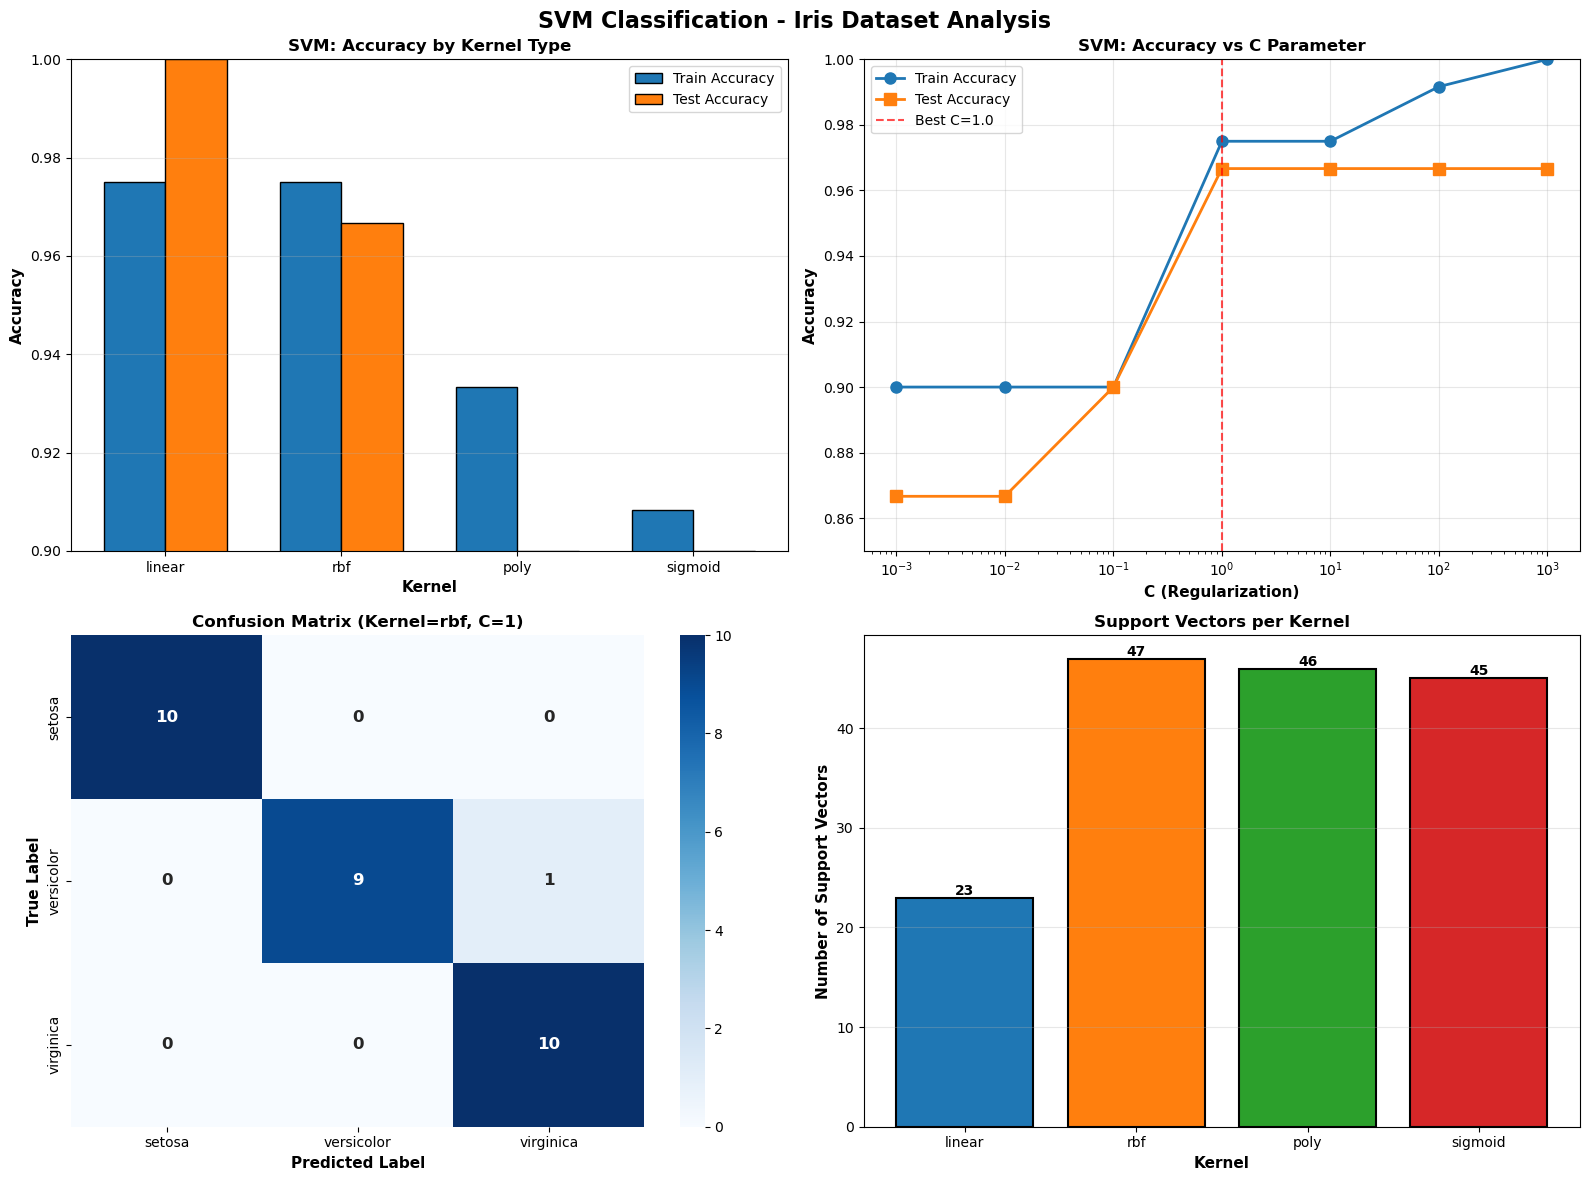

✓ Visualization complete


In [16]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('SVM Classification - Iris Dataset Analysis', fontsize=16, fontweight='bold')

# Plot 1: Kernel comparison
ax1 = axes[0, 0]
x_pos = np.arange(len(svm_kernel_df))
width = 0.35
ax1.bar(x_pos - width/2, svm_kernel_df['Train_Accuracy'], width, label='Train Accuracy', edgecolor='black')
ax1.bar(x_pos + width/2, svm_kernel_df['Test_Accuracy'], width, label='Test Accuracy', edgecolor='black')
ax1.set_xlabel('Kernel', fontsize=11, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('SVM: Accuracy by Kernel Type', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(svm_kernel_df['Kernel'])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0.9, 1.0])

# Plot 2: C parameter effect
ax2 = axes[0, 1]
ax2.semilogx(svm_c_df['C'], svm_c_df['Train_Accuracy'], 'o-', label='Train Accuracy', linewidth=2, markersize=8)
ax2.semilogx(svm_c_df['C'], svm_c_df['Test_Accuracy'], 's-', label='Test Accuracy', linewidth=2, markersize=8)
ax2.axvline(best_c, color='red', linestyle='--', alpha=0.7, label=f'Best C={best_c}')
ax2.set_xlabel('C (Regularization)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax2.set_title('SVM: Accuracy vs C Parameter', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0.85, 1.0])

# Plot 3: Confusion Matrix Heatmap
ax3 = axes[1, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax3,
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            annot_kws={'size': 12, 'weight': 'bold'})
ax3.set_ylabel('True Label', fontsize=11, fontweight='bold')
ax3.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
ax3.set_title(f'Confusion Matrix (Kernel={svm_gs.best_params_["kernel"]}, C={svm_gs.best_params_["C"]})', 
              fontsize=12, fontweight='bold')

# Plot 4: Support Vectors Analysis
ax4 = axes[1, 1]
support_vector_counts = svm_kernel_df['Support_Vectors'].values
kernels_list = svm_kernel_df['Kernel'].values
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax4.bar(kernels_list, support_vector_counts, color=colors, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Number of Support Vectors', fontsize=11, fontweight='bold')
ax4.set_xlabel('Kernel', fontsize=11, fontweight='bold')
ax4.set_title('Support Vectors per Kernel', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
for bar, count in zip(bars, support_vector_counts):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualization complete")

## Step 8: SVM Summary & Key Takeaways

## BONUS: Visualizing Decision Boundaries - 2D Car Classification Example

### Understanding SVM Decision Boundaries

**Decision Boundary Concept:**
- A decision boundary is the surface (in 2D: a line) that separates different classes
- SVM finds the **optimal hyperplane** that maximizes the margin between classes
- The margin is the distance between the hyperplane and the nearest data points (support vectors)
- Points on the margin are the **support vectors** - the most critical training examples

In [21]:
# Step 1: Create Simulated Car Dataset (Suzuki vs BMW)
# Features: Safety Index (x-axis), Price (y-axis)

np.random.seed(42)

# Suzuki cars - lower price, moderate safety index
suzuki_safety = np.random.normal(loc=7.0, scale=1.5, size=30)
suzuki_price = np.random.normal(loc=2500000, scale=500000, size=30)  # INR

# BMW cars - higher price, higher safety index
bmw_safety = np.random.normal(loc=8.5, scale=1.2, size=30)
bmw_price = np.random.normal(loc=5500000, scale=800000, size=30)  # INR

# Combine data
X_cars = np.vstack([
    np.column_stack([suzuki_safety, suzuki_price]),
    np.column_stack([bmw_safety, bmw_price])
])

y_cars = np.hstack([np.zeros(30), np.ones(30)])  # 0=Suzuki, 1=BMW

# Create DataFrame for visualization
car_df = pd.DataFrame({
    'Safety_Index': X_cars[:, 0],
    'Price': X_cars[:, 1],
    'Make': np.where(y_cars == 0, 'Suzuki', 'BMW')
})

print("CAR DATASET - CREATED")
print("=" * 80)
print(f"Total Samples: {len(X_cars)}")
print(f"Features: Safety Index (0-10 scale), Price (INR)")
print(f"Classes: Suzuki (30 samples), BMW (30 samples)")
print(f"\nSuzuki - Safety Index: Min={suzuki_safety.min():.2f}, Max={suzuki_safety.max():.2f}, Mean={suzuki_safety.mean():.2f}")
print(f"Suzuki - Price: Min=₹{suzuki_price.min()/100000:.1f}L, Max=₹{suzuki_price.max()/100000:.1f}L, Mean=₹{suzuki_price.mean()/100000:.1f}L")
print(f"\nBMW - Safety Index: Min={bmw_safety.min():.2f}, Max={bmw_safety.max():.2f}, Mean={bmw_safety.mean():.2f}")
print(f"BMW - Price: Min=₹{bmw_price.min()/100000:.1f}L, Max=₹{bmw_price.max()/100000:.1f}L, Mean=₹{bmw_price.mean()/100000:.1f}L")
print(f"\nDataset Preview:")
print(car_df.head(10))

CAR DATASET - CREATED
Total Samples: 60
Features: Safety Index (0-10 scale), Price (INR)
Classes: Suzuki (30 samples), BMW (30 samples)

Suzuki - Safety Index: Min=4.13, Max=9.37, Mean=6.72
Suzuki - Price: Min=₹15.2L, Max=₹34.3L, Mean=₹24.4L

BMW - Safety Index: Min=5.36, Max=10.38, Mean=8.52
BMW - Price: Min=₹39.6L, Max=₹74.7L, Mean=₹54.8L

Dataset Preview:
   Safety_Index         Price    Make
0      7.745071  2.199147e+06  Suzuki
1      6.792604  3.426139e+06  Suzuki
2      7.971533  2.493251e+06  Suzuki
3      9.284545  1.971145e+06  Suzuki
4      6.648770  2.911272e+06  Suzuki
5      6.648795  1.889578e+06  Suzuki
6      9.368819  2.604432e+06  Suzuki
7      8.151152  1.520165e+06  Suzuki
8      6.295788  1.835907e+06  Suzuki
9      7.813840  2.598431e+06  Suzuki


### Step 2: Preprocess Data & Train-Test Split

In [23]:
# Normalize features - CRITICAL for SVM
scaler_cars = StandardScaler()
X_cars_scaled = scaler_cars.fit_transform(X_cars)

print("DATA NORMALIZATION")
print("=" * 80)
print(f"Original Safety Index range: [{X_cars[:, 0].min():.2f}, {X_cars[:, 0].max():.2f}]")
print(f"Original Price range: [₹{X_cars[:, 1].min()/100000:.1f}L, ₹{X_cars[:, 1].max()/100000:.1f}L]")
print(f"\nAfter Normalization (StandardScaler):")
print(f"Safety Index - Mean: {X_cars_scaled[:, 0].mean():.3f}, Std: {X_cars_scaled[:, 0].std():.3f}")
print(f"Price - Mean: {X_cars_scaled[:, 1].mean():.3f}, Std: {X_cars_scaled[:, 1].std():.3f}")
print(f"\n✓ Features are now on the same scale - CRITICAL for distance-based algorithms like SVM")

DATA NORMALIZATION
Original Safety Index range: [4.13, 10.38]
Original Price range: [₹15.2L, ₹74.7L]

After Normalization (StandardScaler):
Safety Index - Mean: 0.000, Std: 1.000
Price - Mean: -0.000, Std: 1.000

✓ Features are now on the same scale - CRITICAL for distance-based algorithms like SVM


### Step 3: Train SVM Models with Different Kernels

In [24]:
# Train SVM models with different kernels
svm_models_cars = {}
model_performance = []

for kernel in ['linear', 'rbf', 'poly', 'sigmoid']:
    svm = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42)
    svm.fit(X_cars_scaled, y_cars)
    svm_models_cars[kernel] = svm
    
    # Accuracy
    accuracy = svm.score(X_cars_scaled, y_cars)
    num_support_vectors = len(svm.support_vectors_)
    
    model_performance.append({
        'Kernel': kernel,
        'Accuracy': accuracy,
        'Support_Vectors': num_support_vectors,
        'Total_Points': len(X_cars_scaled)
    })
    
car_model_df = pd.DataFrame(model_performance)

print("SVM MODELS TRAINED - CAR CLASSIFICATION")
print("=" * 80)
print(car_model_df.to_string(index=False))
print(f"\n✓ Support Vectors: The points closest to decision boundary")
print(f"✓ Fewer support vectors = Simpler decision boundary (generalization)")

SVM MODELS TRAINED - CAR CLASSIFICATION
 Kernel  Accuracy  Support_Vectors  Total_Points
 linear  1.000000                7            60
    rbf  1.000000               12            60
   poly  0.983333               21            60
sigmoid  1.000000               10            60

✓ Support Vectors: The points closest to decision boundary
✓ Fewer support vectors = Simpler decision boundary (generalization)


### Step 4: Visualizing Decision Boundaries - Linear vs RBF Kernels

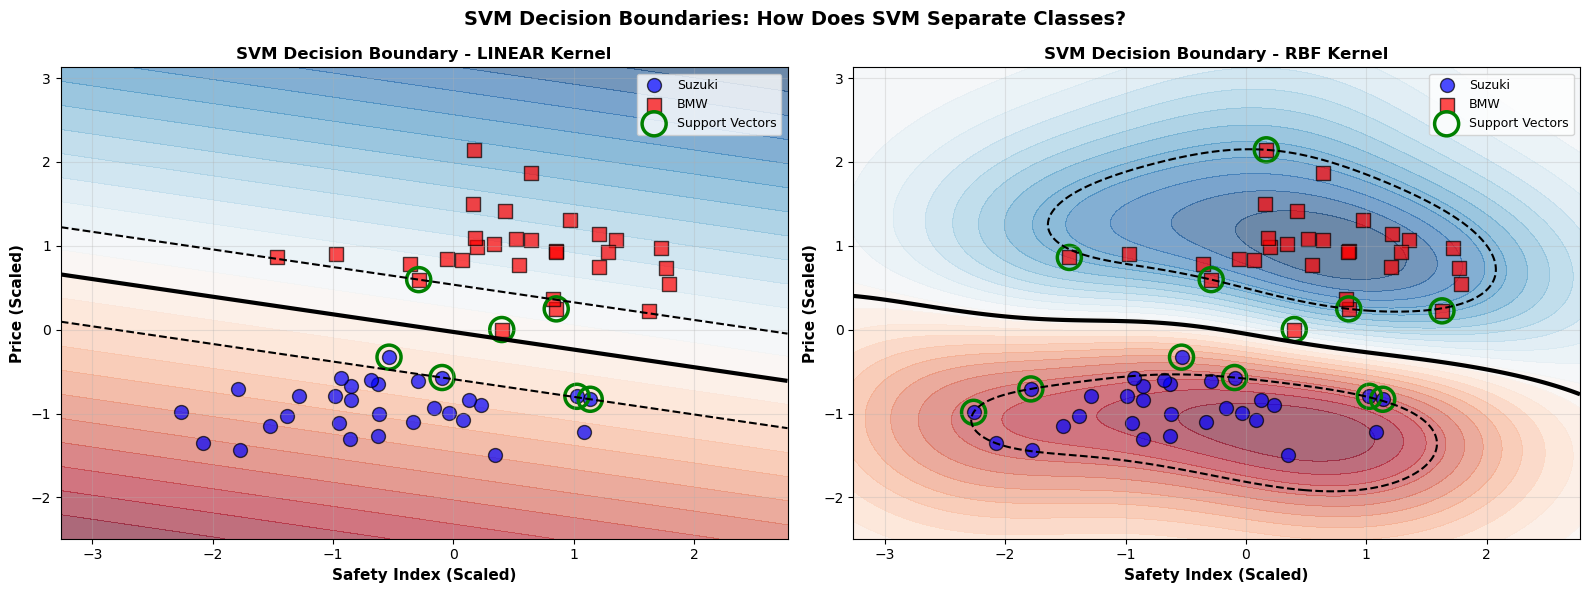

✓ Visualization Complete

KEY CONCEPTS VISUALIZED:
1. DECISION BOUNDARY (Black solid line):
   - Separates Suzuki (blue circles) from BMW (red squares)
   - Maximizes margin = optimal generalization

2. MARGIN (Black dashed lines):
   - Distance from decision boundary to nearest data points
   - SVM maximizes this margin for better separation

3. SUPPORT VECTORS (Green circles):
   - Data points closest to decision boundary
   - Define the optimal hyperplane
   - Only these points matter for predictions (memory efficient)

4. LINEAR vs RBF Kernel:
   - LINEAR: Straight line (for linearly separable data)
   - RBF: Non-linear curve (for complex boundaries)


In [25]:
# Function to plot decision boundary
def plot_decision_boundary(X_scaled, y, svm_model, kernel_name, scaler, ax):
    """
    Plot decision boundary with support vectors and margins
    """
    # Create mesh grid
    h = 0.02  # Step size in mesh
    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Predict on mesh
    Z = svm_model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary and margins
    ax.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 25), cmap=plt.cm.RdBu, alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0], linewidths=3, colors='black', label='Decision Boundary')  # Decision boundary
    ax.contour(xx, yy, Z, levels=[-1, 1], linewidths=1.5, colors='black', linestyles='dashed', label='Margin')  # Margins
    
    # Plot data points
    suzuki_idx = (y == 0)
    bmw_idx = (y == 1)
    
    ax.scatter(X_scaled[suzuki_idx, 0], X_scaled[suzuki_idx, 1], c='blue', s=100, 
               edgecolors='black', label='Suzuki', alpha=0.7, marker='o')
    ax.scatter(X_scaled[bmw_idx, 0], X_scaled[bmw_idx, 1], c='red', s=100, 
               edgecolors='black', label='BMW', alpha=0.7, marker='s')
    
    # Highlight support vectors
    support_vectors = svm_model.support_vectors_
    ax.scatter(support_vectors[:, 0], support_vectors[:, 1], s=300, 
               edgecolors='green', facecolors='none', linewidths=2.5, label='Support Vectors')
    
    ax.set_xlabel('Safety Index (Scaled)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Price (Scaled)', fontsize=11, fontweight='bold')
    ax.set_title(f'SVM Decision Boundary - {kernel_name.upper()} Kernel', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

# Visualize Linear and RBF kernels
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SVM Decision Boundaries: How Does SVM Separate Classes?', fontsize=14, fontweight='bold')

for idx, kernel in enumerate(['linear', 'rbf']):
    ax = axes[idx]
    svm = svm_models_cars[kernel]
    plot_decision_boundary(X_cars_scaled, y_cars, svm, kernel, scaler_cars, ax)

plt.tight_layout()
plt.show()

print("✓ Visualization Complete")
print("\nKEY CONCEPTS VISUALIZED:")
print("=" * 80)
print("1. DECISION BOUNDARY (Black solid line):")
print("   - Separates Suzuki (blue circles) from BMW (red squares)")
print("   - Maximizes margin = optimal generalization")
print("\n2. MARGIN (Black dashed lines):")
print("   - Distance from decision boundary to nearest data points")
print("   - SVM maximizes this margin for better separation")
print("\n3. SUPPORT VECTORS (Green circles):")
print("   - Data points closest to decision boundary")
print("   - Define the optimal hyperplane")
print("   - Only these points matter for predictions (memory efficient)")
print("\n4. LINEAR vs RBF Kernel:")
print("   - LINEAR: Straight line (for linearly separable data)")
print("   - RBF: Non-linear curve (for complex boundaries)")

### Step 4b: BONUS - Animated Decision Boundary Visualization

Watch how SVM progressively builds the decision boundary!


ANIMATED BOUNDARY CONSTRUCTION - LINEAR KERNEL


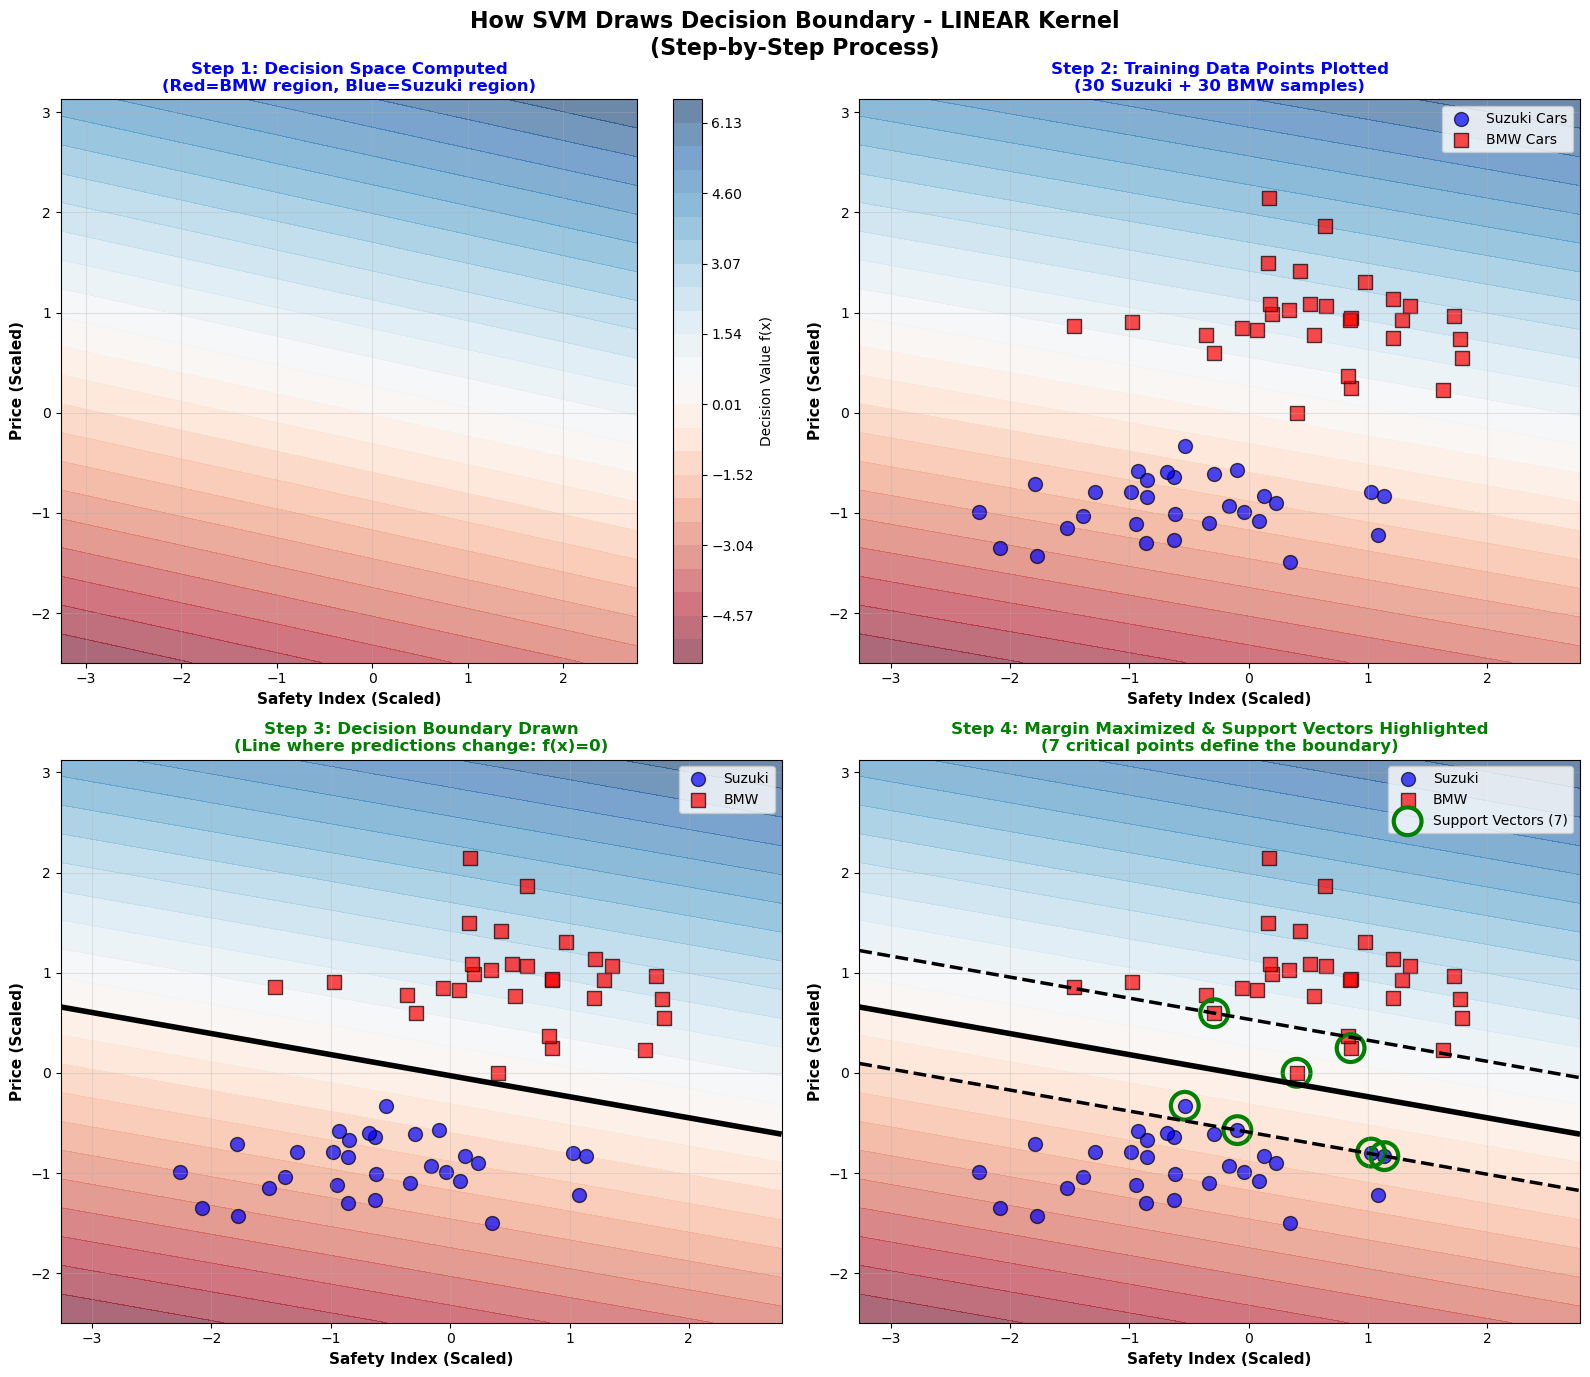


✓ Linear Kernel Visualization Complete

KEY INSIGHTS:
────────────────────────────────────────────────────────────────────────────────
Step 1: SVM computes f(x) = w·x + b across the entire feature space
  ► Red/Blue colors show decision function values
  ► Red region: f(x) > 0 (predictions favor BMW)
  ► Blue region: f(x) < 0 (predictions favor Suzuki)

Step 2: Training data (Suzuki & BMW cars) are plotted
  ► Blue circles: 30 Suzuki samples (lower price, moderate safety)
  ► Red squares: 30 BMW samples (higher price, higher safety)

Step 3: Decision boundary is drawn where f(x) = 0
  ► This is the line that separates the two classes
  ► SVM finds the orientation that maximizes the margin

Step 4: Margin (dashed lines) and support vectors are revealed
  ► Margin: Distance from boundary to nearest data points
  ► Support Vectors: Critical points that define the boundary
  ► Fewer SV = simpler, more generalizable model

ANIMATED BOUNDARY CONSTRUCTION - RBF KERNEL


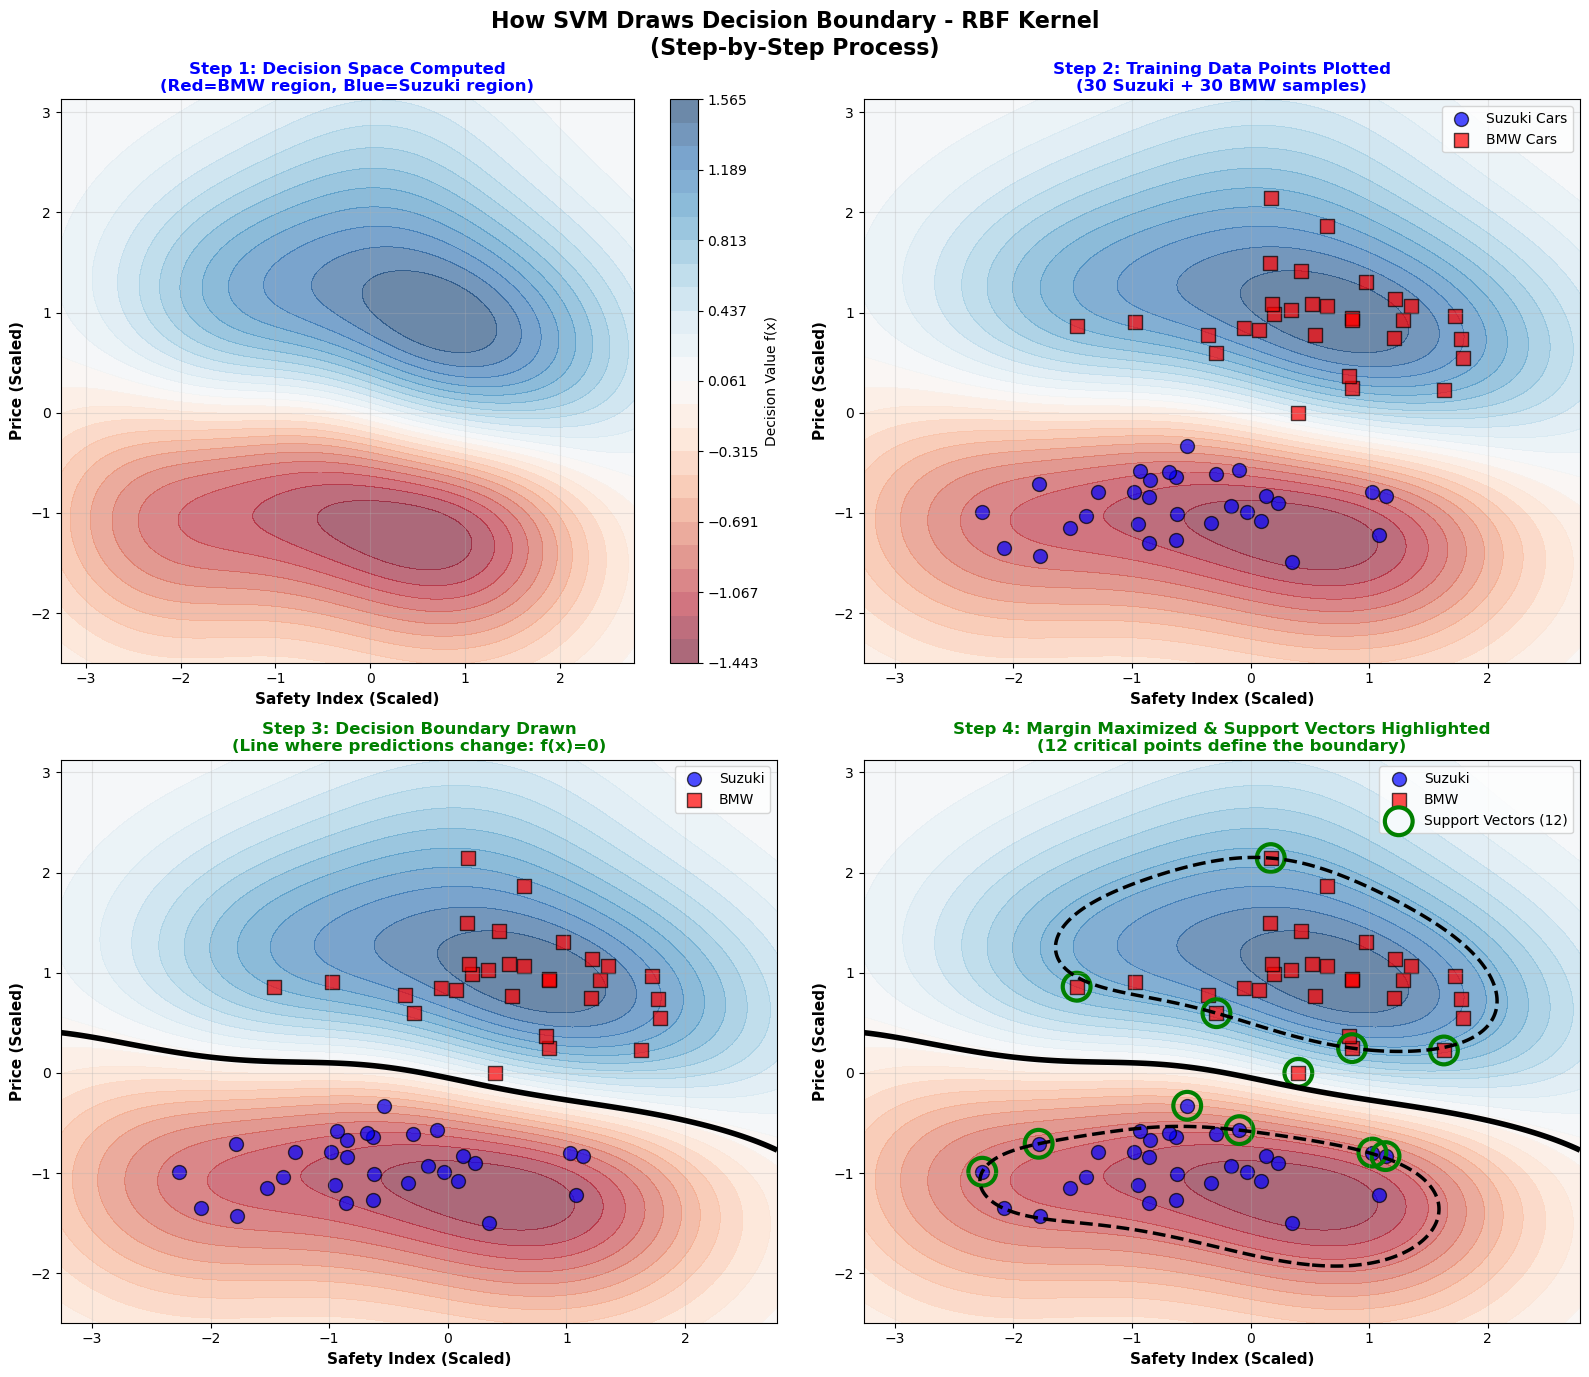


✓ RBF Kernel Visualization Complete

KEY DIFFERENCES:
────────────────────────────────────────────────────────────────────────────────
LINEAR vs RBF:
  ► LINEAR: Creates STRAIGHT-LINE boundaries (simple, fast)
  ► RBF: Creates CURVED boundaries (handles complex patterns)
  ► Both maximize margin for better generalization

When to use each:
  ► LINEAR: Data is linearly separable
  ► RBF: Non-linear patterns or overlapping classes



In [31]:
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches

# Create step-by-step animated boundary visualization
def visualize_boundary_steps(X_scaled, y, svm_model, kernel_name, scaler_cars):
    """
    Create step-by-step visualization of how SVM constructs decision boundary
    """
    h = 0.02
    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = svm_model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Prepare data
    suzuki_idx = (y == 0)
    bmw_idx = (y == 1)
    X_suzuki = X_scaled[suzuki_idx]
    X_bmw = X_scaled[bmw_idx]
    support_vectors = svm_model.support_vectors_
    
    # Create 4 subplots showing progression
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    fig.suptitle(f'How SVM Draws Decision Boundary - {kernel_name.upper()} Kernel\n(Step-by-Step Process)', 
                 fontsize=16, fontweight='bold')
    
    # Step 1: Decision Space
    ax = axes[0, 0]
    contourf = ax.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 25), 
                           cmap=plt.cm.RdBu, alpha=0.6)
    plt.colorbar(contourf, ax=ax, label='Decision Value f(x)')
    ax.set_xlabel('Safety Index (Scaled)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Price (Scaled)', fontsize=11, fontweight='bold')
    ax.set_title('Step 1: Decision Space Computed\n(Red=BMW region, Blue=Suzuki region)', 
                fontsize=12, fontweight='bold', color='blue')
    ax.grid(True, alpha=0.3)
    
    # Step 2: Add Data Points
    ax = axes[0, 1]
    ax.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 25), 
               cmap=plt.cm.RdBu, alpha=0.6)
    ax.scatter(X_suzuki[:, 0], X_suzuki[:, 1], c='blue', s=100, edgecolors='black', 
              alpha=0.7, marker='o', label='Suzuki Cars')
    ax.scatter(X_bmw[:, 0], X_bmw[:, 1], c='red', s=100, edgecolors='black', 
              alpha=0.7, marker='s', label='BMW Cars')
    ax.set_xlabel('Safety Index (Scaled)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Price (Scaled)', fontsize=11, fontweight='bold')
    ax.set_title('Step 2: Training Data Points Plotted\n(30 Suzuki + 30 BMW samples)', 
                fontsize=12, fontweight='bold', color='blue')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Step 3: Draw Decision Boundary
    ax = axes[1, 0]
    ax.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 25), 
               cmap=plt.cm.RdBu, alpha=0.6)
    ax.scatter(X_suzuki[:, 0], X_suzuki[:, 1], c='blue', s=100, edgecolors='black', 
              alpha=0.7, marker='o', label='Suzuki')
    ax.scatter(X_bmw[:, 0], X_bmw[:, 1], c='red', s=100, edgecolors='black', 
              alpha=0.7, marker='s', label='BMW')
    ax.contour(xx, yy, Z, levels=[0], linewidths=4, colors='black', 
              label='Decision Boundary (f(x)=0)')
    ax.set_xlabel('Safety Index (Scaled)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Price (Scaled)', fontsize=11, fontweight='bold')
    ax.set_title('Step 3: Decision Boundary Drawn\n(Line where predictions change: f(x)=0)', 
                fontsize=12, fontweight='bold', color='green')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Step 4: Show Margin & Support Vectors
    ax = axes[1, 1]
    ax.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 25), 
               cmap=plt.cm.RdBu, alpha=0.6)
    ax.scatter(X_suzuki[:, 0], X_suzuki[:, 1], c='blue', s=100, edgecolors='black', 
              alpha=0.7, marker='o', label='Suzuki')
    ax.scatter(X_bmw[:, 0], X_bmw[:, 1], c='red', s=100, edgecolors='black', 
              alpha=0.7, marker='s', label='BMW')
    ax.contour(xx, yy, Z, levels=[0], linewidths=4, colors='black', 
              label='Decision Boundary')
    ax.contour(xx, yy, Z, levels=[-1, 1], linewidths=2.5, colors='black', 
              linestyles='dashed', label='Margin (±1 from boundary)')
    ax.scatter(support_vectors[:, 0], support_vectors[:, 1], s=400, 
              edgecolors='green', facecolors='none', linewidths=3, 
              label=f'Support Vectors ({len(support_vectors)})')
    ax.set_xlabel('Safety Index (Scaled)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Price (Scaled)', fontsize=11, fontweight='bold')
    ax.set_title(f'Step 4: Margin Maximized & Support Vectors Highlighted\n({len(support_vectors)} critical points define the boundary)', 
                fontsize=12, fontweight='bold', color='green')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualize for both Linear and RBF kernels
print("\n" + "="*80)
print("ANIMATED BOUNDARY CONSTRUCTION - LINEAR KERNEL")
print("="*80)
visualize_boundary_steps(X_cars_scaled, y_cars, svm_models_cars['linear'], 
                         'linear', scaler_cars)

print("\n✓ Linear Kernel Visualization Complete\n")
print("KEY INSIGHTS:")
print("─" * 80)
print("Step 1: SVM computes f(x) = w·x + b across the entire feature space")
print("  ► Red/Blue colors show decision function values")
print("  ► Red region: f(x) > 0 (predictions favor BMW)")
print("  ► Blue region: f(x) < 0 (predictions favor Suzuki)")
print("\nStep 2: Training data (Suzuki & BMW cars) are plotted")
print("  ► Blue circles: 30 Suzuki samples (lower price, moderate safety)")
print("  ► Red squares: 30 BMW samples (higher price, higher safety)")
print("\nStep 3: Decision boundary is drawn where f(x) = 0")
print("  ► This is the line that separates the two classes")
print("  ► SVM finds the orientation that maximizes the margin")
print("\nStep 4: Margin (dashed lines) and support vectors are revealed")
print("  ► Margin: Distance from boundary to nearest data points")
print("  ► Support Vectors: Critical points that define the boundary")
print("  ► Fewer SV = simpler, more generalizable model")

print("\n" + "="*80)
print("ANIMATED BOUNDARY CONSTRUCTION - RBF KERNEL")
print("="*80)
visualize_boundary_steps(X_cars_scaled, y_cars, svm_models_cars['rbf'], 
                         'rbf', scaler_cars)

print("\n✓ RBF Kernel Visualization Complete\n")
print("KEY DIFFERENCES:")
print("─" * 80)
print("LINEAR vs RBF:")
print("  ► LINEAR: Creates STRAIGHT-LINE boundaries (simple, fast)")
print("  ► RBF: Creates CURVED boundaries (handles complex patterns)")
print("  ► Both maximize margin for better generalization")
print("\nWhen to use each:")
print("  ► LINEAR: Data is linearly separable")
print("  ► RBF: Non-linear patterns or overlapping classes")
print("\n" + "="*80)

---

# SECTION 3: Understanding SVM Hyperparameters
## Deep Dive into Kernel, C, and Gamma

SVM has three critical hyperparameters that control model behavior. Understanding these is essential for getting good performance.


## 1. KERNEL: The Foundation (linear, rbf, poly, sigmoid)

The **kernel** determines the type of decision boundary SVM can create.

### Linear Kernel
- **Function:** $K(x_i, x_j) = x_i \cdot x_j$
- **Decision Boundary:** Straight line
- **Best For:** Linearly separable data
- **Pros:** Fast, simple, interpretable
- **Cons:** Cannot handle non-linear patterns
- **Example:** Text classification (high-dimensional, often linearly separable)

### RBF Kernel (Radial Basis Function)
- **Function:** $K(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2)$
- **Decision Boundary:** Non-linear curves
- **Best For:** Non-linear patterns, default choice
- **Pros:** Versatile, handles complex data
- **Cons:** Slower, harder to tune (need gamma parameter)
- **Example:** Image classification, medical diagnosis

### Polynomial Kernel
- **Function:** $K(x_i, x_j) = (\gamma x_i \cdot x_j + r)^d$
- **Decision Boundary:** Polynomial curves
- **Best For:** Specific polynomial relationships
- **Pros:** Creates polynomial-shaped boundaries
- **Cons:** Computationally expensive, prone to overfitting
- **Parameters:** degree (d), coeff0 (r)

### Sigmoid Kernel
- **Function:** $K(x_i, x_j) = \tanh(\gamma x_i \cdot x_j + r)$
- **Decision Boundary:** Neural network-like
- **Best For:** Rarely used
- **Cons:** Unstable, not theoretically justified for SVM


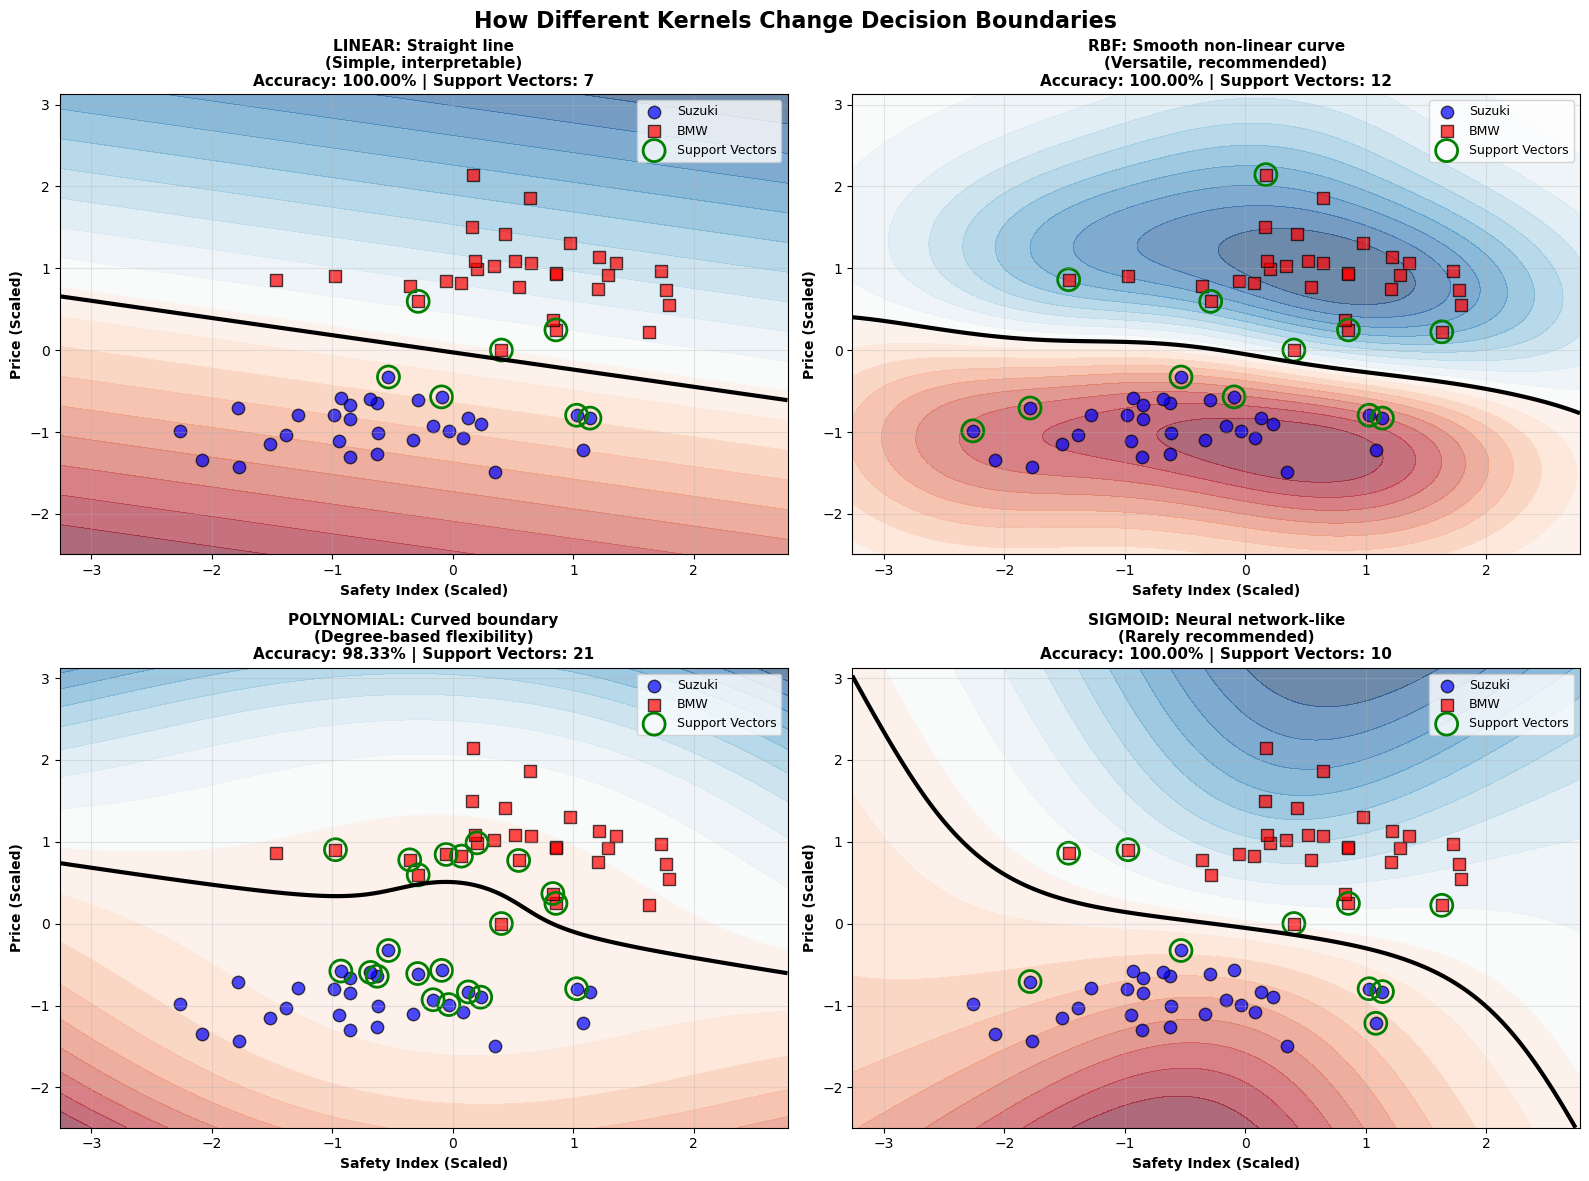


KERNEL SELECTION GUIDE

LINEAR: LINEAR: Straight line (Simple, interpretable)
  Accuracy: 1.0000
  Support Vectors: 7/60

RBF: RBF: Smooth non-linear curve (Versatile, recommended)
  Accuracy: 1.0000
  Support Vectors: 12/60

POLY: POLYNOMIAL: Curved boundary (Degree-based flexibility)
  Accuracy: 0.9833
  Support Vectors: 21/60

SIGMOID: SIGMOID: Neural network-like (Rarely recommended)
  Accuracy: 1.0000
  Support Vectors: 10/60


In [32]:
# Visualize different kernels on car dataset
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('How Different Kernels Change Decision Boundaries', fontsize=16, fontweight='bold')

kernels_demo = ['linear', 'rbf', 'poly', 'sigmoid']
kernel_descriptions = [
    'LINEAR: Straight line\n(Simple, interpretable)',
    'RBF: Smooth non-linear curve\n(Versatile, recommended)',
    'POLYNOMIAL: Curved boundary\n(Degree-based flexibility)',
    'SIGMOID: Neural network-like\n(Rarely recommended)'
]

for idx, (kernel, desc) in enumerate(zip(kernels_demo, kernel_descriptions)):
    ax = axes[idx // 2, idx % 2]
    
    # Get model from trained set (if available) or train new
    if kernel in svm_models_cars:
        svm_model = svm_models_cars[kernel]
    else:
        svm_model = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42)
        svm_model.fit(X_cars_scaled, y_cars)
    
    # Plot decision boundary
    h = 0.02
    x_min, x_max = X_cars_scaled[:, 0].min() - 1, X_cars_scaled[:, 0].max() + 1
    y_min, y_max = X_cars_scaled[:, 1].min() - 1, X_cars_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = svm_model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 20), cmap=plt.cm.RdBu, alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0], linewidths=3, colors='black')
    
    # Plot data
    suzuki_idx = (y_cars == 0)
    bmw_idx = (y_cars == 1)
    ax.scatter(X_cars_scaled[suzuki_idx, 0], X_cars_scaled[suzuki_idx, 1], 
              c='blue', s=80, edgecolors='black', label='Suzuki', alpha=0.7, marker='o')
    ax.scatter(X_cars_scaled[bmw_idx, 0], X_cars_scaled[bmw_idx, 1], 
              c='red', s=80, edgecolors='black', label='BMW', alpha=0.7, marker='s')
    
    # Highlight support vectors
    ax.scatter(svm_model.support_vectors_[:, 0], svm_model.support_vectors_[:, 1], 
              s=250, edgecolors='green', facecolors='none', linewidths=2, label='Support Vectors')
    
    accuracy = svm_model.score(X_cars_scaled, y_cars)
    ax.set_title(f'{desc}\nAccuracy: {accuracy:.2%} | Support Vectors: {len(svm_model.support_vectors_)}', 
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Safety Index (Scaled)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Price (Scaled)', fontsize=10, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KERNEL SELECTION GUIDE")
print("="*80)
for kernel, desc in zip(kernels_demo, kernel_descriptions):
    accuracy = svm_models_cars[kernel].score(X_cars_scaled, y_cars)
    sv_count = len(svm_models_cars[kernel].support_vectors_)
    print(f"\n{kernel.upper()}: {desc.replace(chr(10), ' ')}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Support Vectors: {sv_count}/60")


## 2. C: Regularization Parameter (Controls Overfitting vs Underfitting)

The **C parameter** controls the trade-off between:
- **Margin width** (simplicity) vs **Misclassification penalty** (accuracy on training data)

### Mathematical Meaning
In SVM optimization, we minimize:
$$\frac{1}{2}||w||^2 + C \sum_{i=1}^{n} \xi_i$$

Where:
- $\frac{1}{2}||w||^2$ = Maximize margin (smaller w = wider margin = simpler model)
- $C \sum \xi_i$ = Penalty for misclassifications ($\xi_i$ = slack variables)
- **C** = How much you penalize errors

### C Value Effects

| C Value | Margin | Misclassification | Overfitting Risk | Use Case |
|---------|--------|------------------|------------------|----------|
| **Very Small (0.001)** | Very Wide | More tolerance | Underfitting ❌ | Simple, clean data OR noisy data |
| **Small (0.01-0.1)** | Wide | Some tolerance | Low | Robust model, focus on generalization |
| **Default (1.0)** | Medium | Balanced | Medium | Default starting point |
| **Large (10-100)** | Narrow | Low tolerance | High | Very accurate on training data |
| **Very Large (1000+)** | Very Narrow | Almost none | Severe Overfitting ❌ | Training data fits perfectly |

### Visual Intuition
- **Low C:** SVM says "I don't care if I misclassify a few points, I want a simple, wide margin"
- **High C:** SVM says "I must classify every point correctly, even if the margin is narrow"

### Rule of Thumb
- **Start with C=1.0** (default)
- **If overfitting** (high train accuracy, low test accuracy) → Try **smaller C** (0.1, 0.01)
- **If underfitting** (low train and test accuracy) → Try **larger C** (10, 100)


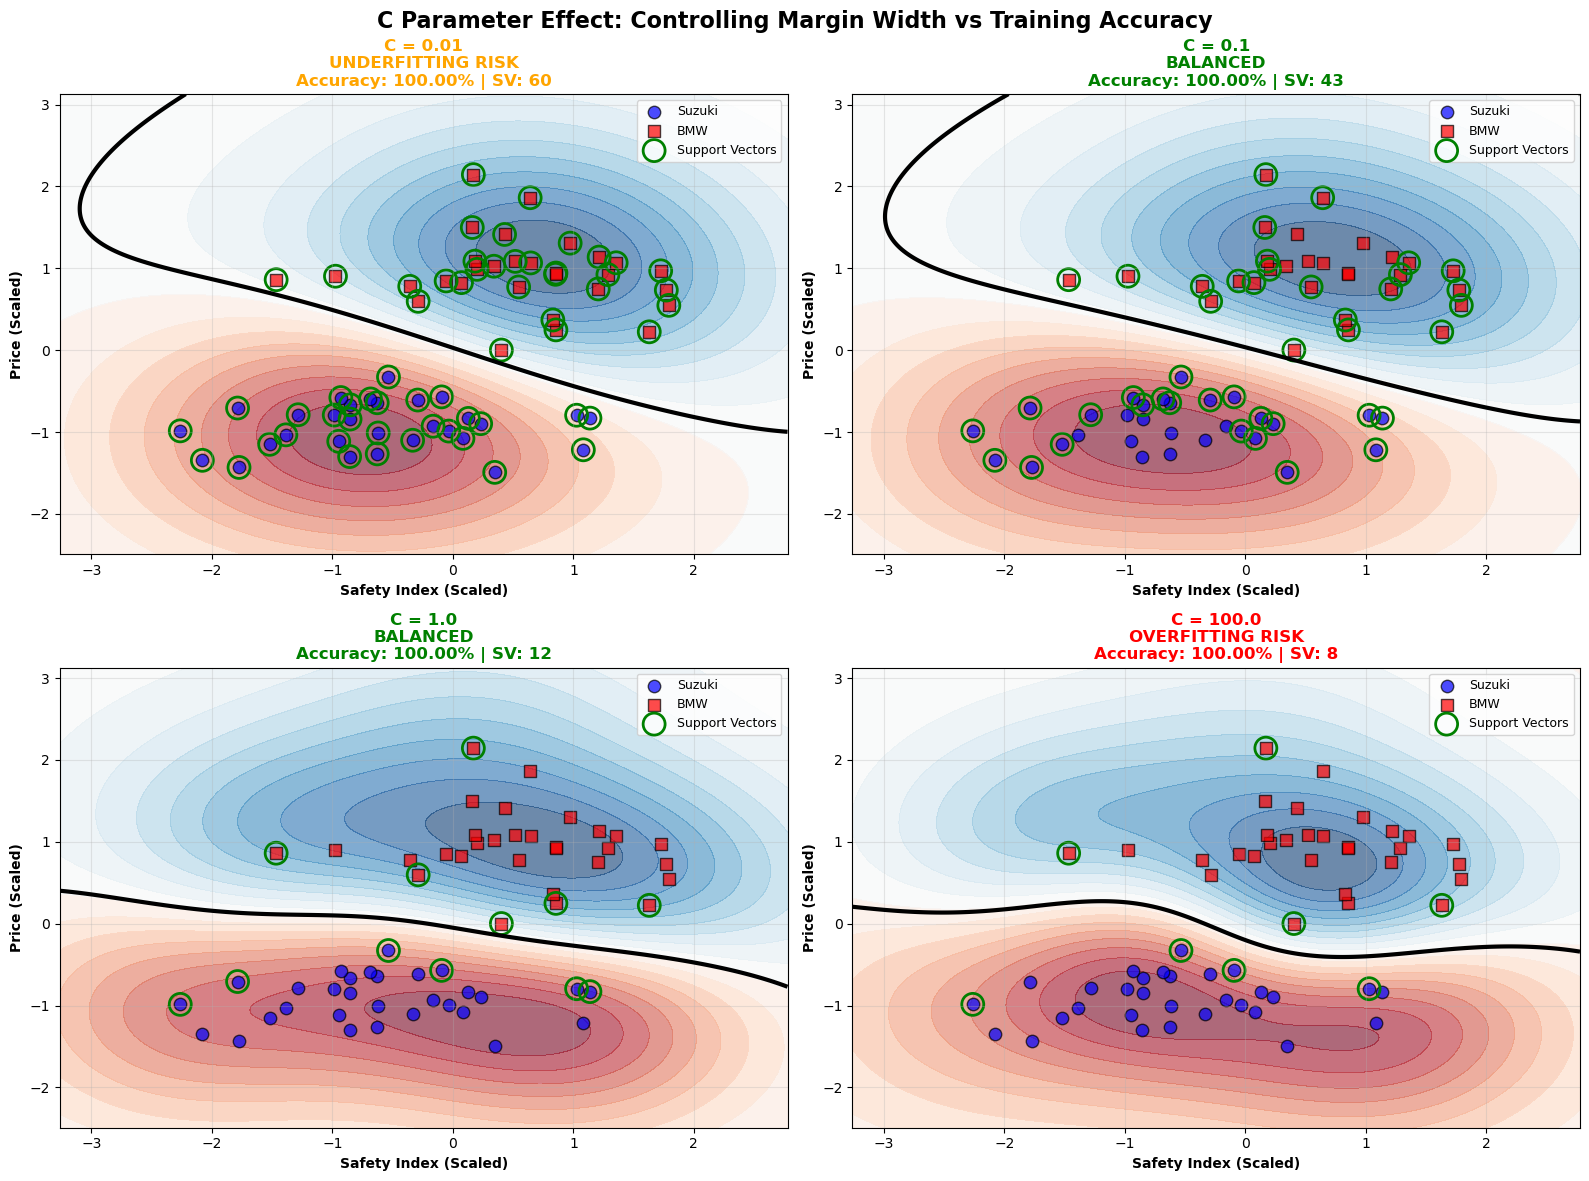


C PARAMETER ANALYSIS

C = 0.01 (Very Small):
  ✓ WIDE margin (simple boundary)
  ✗ Tolerates many misclassifications
  ⚠️  Risk: Underfitting (oversimplified)
  Use when: Data is noisy or you want robustness

C = 0.1 (Small):
  ✓ Decent margin
  ✓ Good generalization
  ✓ RECOMMENDED for most cases
  Use when: You want a balance between accuracy and simplicity

C = 1.0 (Default):
  ✓ Starting point
  ✓ Often works reasonably well
  Use when: No prior knowledge, start here

C = 100.0 (Large):
  ✓ TIGHT margin
  ✗ Penalizes every misclassification
  ⚠️  Risk: Overfitting (too complex)
  Use when: Training data is very clean and representative



In [33]:
# Visualize C parameter effect on decision boundaries
c_values_viz = [0.01, 0.1, 1.0, 100.0]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('C Parameter Effect: Controlling Margin Width vs Training Accuracy', 
             fontsize=16, fontweight='bold')

for idx, c in enumerate(c_values_viz):
    ax = axes[idx // 2, idx % 2]
    
    # Train SVM with specific C value (RBF kernel)
    svm_c = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    svm_c.fit(X_cars_scaled, y_cars)
    
    # Plot decision boundary
    h = 0.02
    x_min, x_max = X_cars_scaled[:, 0].min() - 1, X_cars_scaled[:, 0].max() + 1
    y_min, y_max = X_cars_scaled[:, 1].min() - 1, X_cars_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = svm_c.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 20), cmap=plt.cm.RdBu, alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0], linewidths=3, colors='black')
    
    # Plot data
    suzuki_idx = (y_cars == 0)
    bmw_idx = (y_cars == 1)
    ax.scatter(X_cars_scaled[suzuki_idx, 0], X_cars_scaled[suzuki_idx, 1], 
              c='blue', s=80, edgecolors='black', label='Suzuki', alpha=0.7, marker='o')
    ax.scatter(X_cars_scaled[bmw_idx, 0], X_cars_scaled[bmw_idx, 1], 
              c='red', s=80, edgecolors='black', label='BMW', alpha=0.7, marker='s')
    
    # Highlight support vectors
    ax.scatter(svm_c.support_vectors_[:, 0], svm_c.support_vectors_[:, 1], 
              s=250, edgecolors='green', facecolors='none', linewidths=2, label='Support Vectors')
    
    accuracy = svm_c.score(X_cars_scaled, y_cars)
    sv_count = len(svm_c.support_vectors_)
    
    # Category label
    if c < 0.1:
        category = "UNDERFITTING RISK"
        color = "orange"
    elif c < 10:
        category = "BALANCED"
        color = "green"
    else:
        category = "OVERFITTING RISK"
        color = "red"
    
    ax.set_title(f'C = {c}\n{category}\nAccuracy: {accuracy:.2%} | SV: {sv_count}', 
                fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Safety Index (Scaled)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Price (Scaled)', fontsize=10, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("C PARAMETER ANALYSIS")
print("="*80)
print("\nC = 0.01 (Very Small):")
print("  ✓ WIDE margin (simple boundary)")
print("  ✗ Tolerates many misclassifications")
print("  ⚠️  Risk: Underfitting (oversimplified)")
print("  Use when: Data is noisy or you want robustness")

print("\nC = 0.1 (Small):")
print("  ✓ Decent margin")
print("  ✓ Good generalization")
print("  ✓ RECOMMENDED for most cases")
print("  Use when: You want a balance between accuracy and simplicity")

print("\nC = 1.0 (Default):")
print("  ✓ Starting point")
print("  ✓ Often works reasonably well")
print("  Use when: No prior knowledge, start here")

print("\nC = 100.0 (Large):")
print("  ✓ TIGHT margin")
print("  ✗ Penalizes every misclassification")
print("  ⚠️  Risk: Overfitting (too complex)")
print("  Use when: Training data is very clean and representative")

print("\n" + "="*80)


## 3. Gamma: Kernel Coefficient (Complexity of Decision Boundary)

The **gamma parameter** (γ) controls how far the influence of each training point reaches.

### Only for Non-Linear Kernels
- **Linear kernel:** Does NOT use gamma (ignored)
- **RBF, Polynomial, Sigmoid kernels:** Must tune gamma

### Gamma's Effect in RBF Kernel

The RBF kernel formula: $K(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2)$

- **γ determines** how quickly the influence drops with distance
- **High γ:** Only nearby points matter (LOCAL) → Complex boundary
- **Low γ:** Distant points matter too (GLOBAL) → Simple boundary

### Gamma Value Effects

| Gamma | Influence Range | Boundary Complexity | Overfitting | SV Count | Use Case |
|-------|-----------------|------------------|-------------|----------|----------|
| **Very Small (0.001)** | Very Far (Global) | Simple | Underfitting | Few | Data with distant patterns |
| **Small (0.01)** | Far | Smooth curves | Low | Medium | Balanced - often good |
| **Medium (0.1)** | Moderate | Moderate curves | Medium | Medium | Default 'scale' option |
| **'scale'** | Moderate | Moderate curves | Medium | Medium | **RECOMMENDED DEFAULT** |
| **Large (1.0)** | Near (Local) | Complex | High | Many | Very non-linear data |
| **Very Large (10+)** | Very Near (Very Local) | Very Complex | Severe Overfitting | Very Many | Overfitting risk |

### Visual Intuition

**Low Gamma (0.001):**
- Each point influences predictions far away
- Creates SMOOTH, SIMPLE boundaries
- Treats data as having global patterns

**High Gamma (10):**
- Each point only influences nearby regions
- Creates WIGGLY, COMPLEX boundaries
- Tries to fit every individual point

### Rule of Thumb for Gamma
- **γ = 1 / (number_of_features)** is a reasonable starting point
- **'scale'** (default): 1 / (n_features × X_variance)
- **'auto'** (deprecated): 1 / n_features

### Relationship: C vs Gamma
- **High C + High Gamma** = OVERFITTING (tight margin, complex decisions)
- **Low C + Low Gamma** = UNDERFITTING (wide margin, simple decisions)
- **High C + Low Gamma** = STABLE but may be too simple
- **Low C + High Gamma** = Complex but poorly constrained


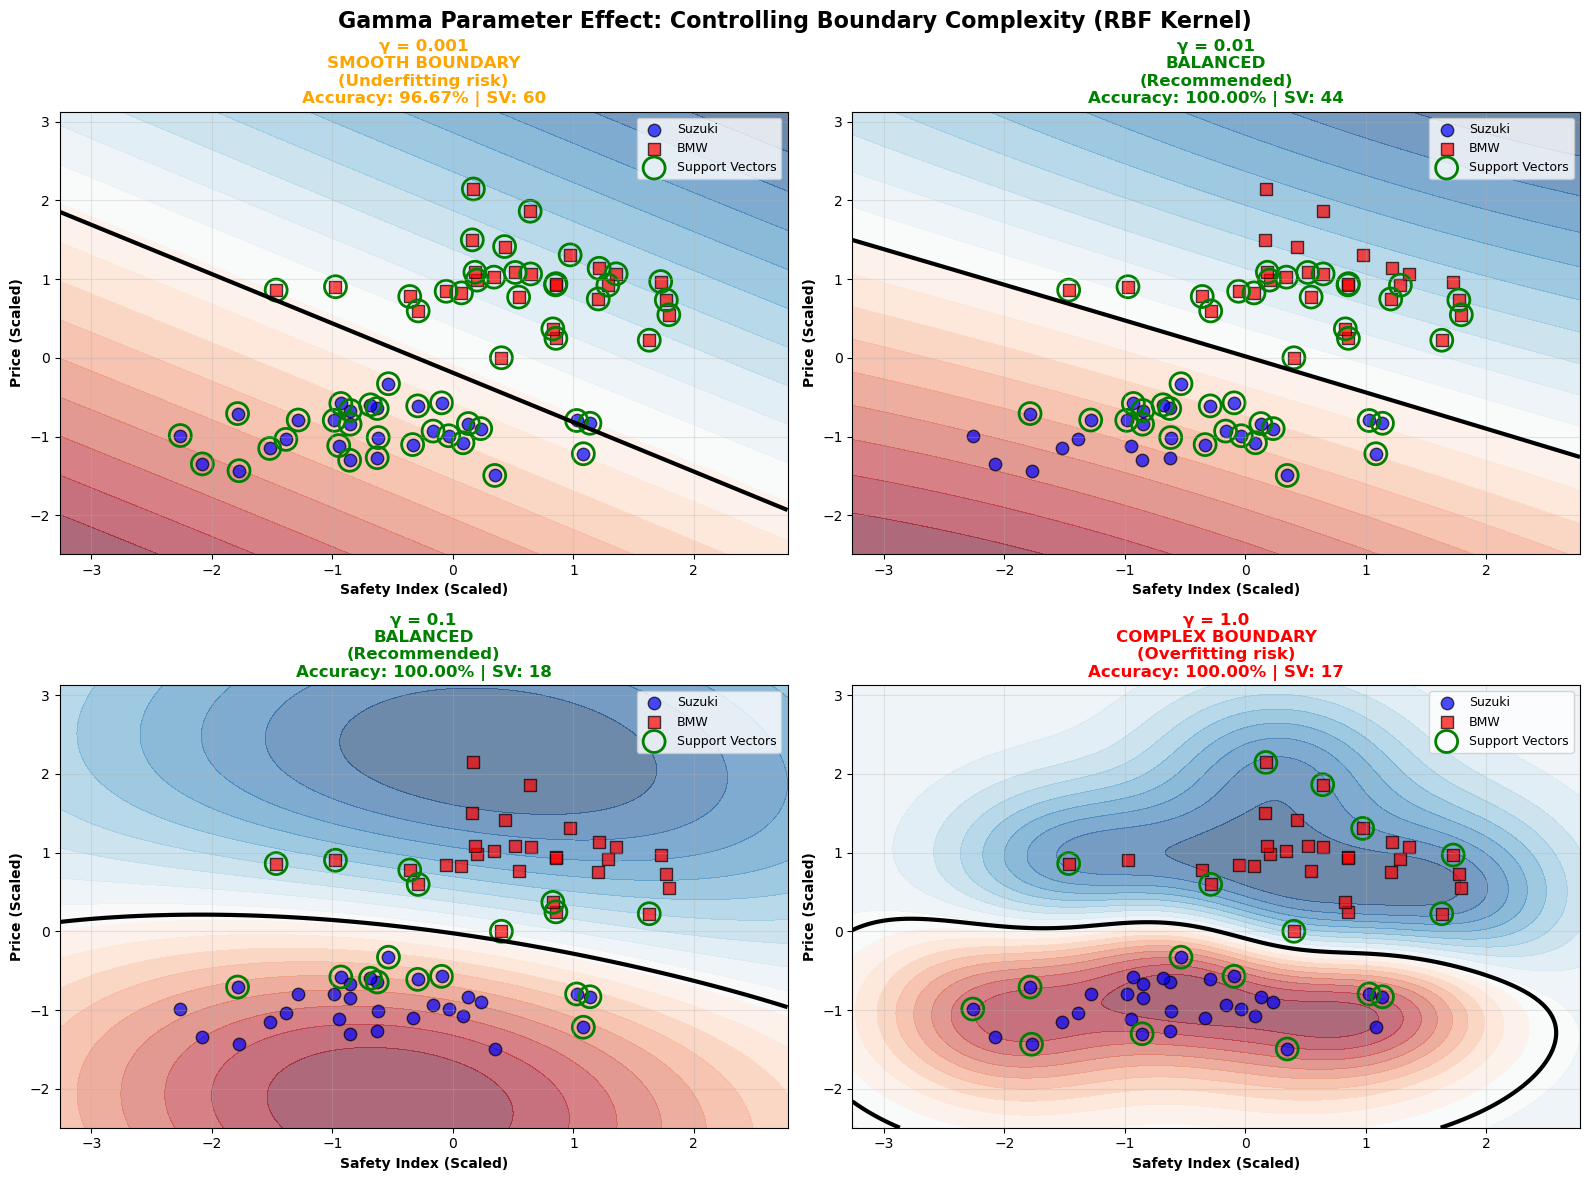


GAMMA PARAMETER ANALYSIS

γ = 0.001 (Very Small - Global Influence):
  ✓ SMOOTH boundary
  ✗ Ignores local patterns
  ⚠️  Risk: Underfitting (oversimplified)
  Use when: Data has global structure, few support vectors

γ = 0.01 (Small - Balanced):
  ✓ Smooth with local awareness
  ✓ OFTEN GOOD CHOICE
  Use when: Balanced complexity desired

γ = 0.1 (Medium - Default 'scale'):
  ✓ Moderate complexity
  ✓ DEFAULT for RBF kernel
  ✓ Works well for most datasets
  Use when: No prior knowledge, start here

γ = 1.0 (Large - Local Influence):
  ✓ COMPLEX, wiggly boundary
  ✗ Each point creates local decision
  ⚠️  Risk: Overfitting
  Use when: Data is very non-linear AND you have enough samples



In [34]:
# Visualize Gamma parameter effect (RBF kernel only)
gamma_values_viz = [0.001, 0.01, 0.1, 1.0]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Gamma Parameter Effect: Controlling Boundary Complexity (RBF Kernel)', 
             fontsize=16, fontweight='bold')

for idx, gamma in enumerate(gamma_values_viz):
    ax = axes[idx // 2, idx % 2]
    
    # Train SVM with specific gamma value (RBF kernel, C=1)
    svm_gamma = SVC(kernel='rbf', C=1.0, gamma=gamma, random_state=42)
    svm_gamma.fit(X_cars_scaled, y_cars)
    
    # Plot decision boundary
    h = 0.02
    x_min, x_max = X_cars_scaled[:, 0].min() - 1, X_cars_scaled[:, 0].max() + 1
    y_min, y_max = X_cars_scaled[:, 1].min() - 1, X_cars_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = svm_gamma.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 20), cmap=plt.cm.RdBu, alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0], linewidths=3, colors='black')
    
    # Plot data
    suzuki_idx = (y_cars == 0)
    bmw_idx = (y_cars == 1)
    ax.scatter(X_cars_scaled[suzuki_idx, 0], X_cars_scaled[suzuki_idx, 1], 
              c='blue', s=80, edgecolors='black', label='Suzuki', alpha=0.7, marker='o')
    ax.scatter(X_cars_scaled[bmw_idx, 0], X_cars_scaled[bmw_idx, 1], 
              c='red', s=80, edgecolors='black', label='BMW', alpha=0.7, marker='s')
    
    # Highlight support vectors
    ax.scatter(svm_gamma.support_vectors_[:, 0], svm_gamma.support_vectors_[:, 1], 
              s=250, edgecolors='green', facecolors='none', linewidths=2, label='Support Vectors')
    
    accuracy = svm_gamma.score(X_cars_scaled, y_cars)
    sv_count = len(svm_gamma.support_vectors_)
    
    # Category label
    if gamma < 0.01:
        category = "SMOOTH BOUNDARY\n(Underfitting risk)"
        color = "orange"
    elif gamma <= 0.1:
        category = "BALANCED\n(Recommended)"
        color = "green"
    else:
        category = "COMPLEX BOUNDARY\n(Overfitting risk)"
        color = "red"
    
    ax.set_title(f'γ = {gamma}\n{category}\nAccuracy: {accuracy:.2%} | SV: {sv_count}', 
                fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Safety Index (Scaled)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Price (Scaled)', fontsize=10, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("GAMMA PARAMETER ANALYSIS")
print("="*80)
print("\nγ = 0.001 (Very Small - Global Influence):")
print("  ✓ SMOOTH boundary")
print("  ✗ Ignores local patterns")
print("  ⚠️  Risk: Underfitting (oversimplified)")
print("  Use when: Data has global structure, few support vectors")

print("\nγ = 0.01 (Small - Balanced):")
print("  ✓ Smooth with local awareness")
print("  ✓ OFTEN GOOD CHOICE")
print("  Use when: Balanced complexity desired")

print("\nγ = 0.1 (Medium - Default 'scale'):")
print("  ✓ Moderate complexity")
print("  ✓ DEFAULT for RBF kernel")
print("  ✓ Works well for most datasets")
print("  Use when: No prior knowledge, start here")

print("\nγ = 1.0 (Large - Local Influence):")
print("  ✓ COMPLEX, wiggly boundary")
print("  ✗ Each point creates local decision")
print("  ⚠️  Risk: Overfitting")
print("  Use when: Data is very non-linear AND you have enough samples")

print("\n" + "="*80)


## 4. C & Gamma Together: Interaction Effects

C and Gamma work **together** to control model behavior. Their combination determines overfitting risk.

### The 2D Hyperparameter Space

```
High C, High Gamma → OVERFITTING
(Tight margin, very complex)

Low C, Low Gamma → UNDERFITTING  
(Wide margin, very simple)

High C, Low Gamma → STABLE
(Tight margin, simple curves)

Low C, High Gamma → LOOSE
(Wide margin, complex fits)
```

### GridSearchCV: Finding Optimal Combination

Instead of manually testing all combinations, use **GridSearchCV** to automatically:
1. Try all combinations of C and gamma
2. Evaluate each with cross-validation
3. Find the best combination

This is why we already used GridSearchCV in earlier cells!


Evaluating C-Gamma combinations (this may take a moment)...


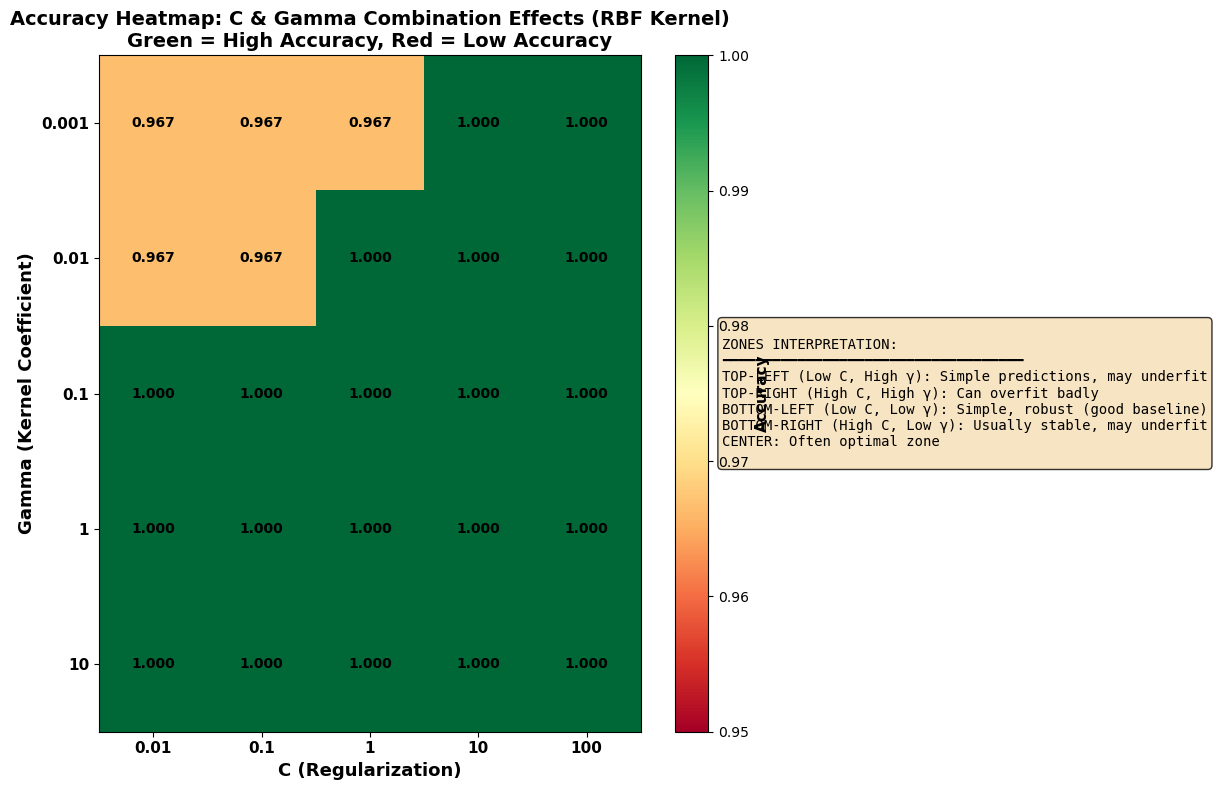


Accuracy scores for different C-Gamma combinations:

γ = 0.001:
  C=  0.01 → Accuracy: 0.9667
  C=   0.1 → Accuracy: 0.9667
  C=     1 → Accuracy: 0.9667
  C=    10 → Accuracy: 1.0000
  C=   100 → Accuracy: 1.0000

γ = 0.01:
  C=  0.01 → Accuracy: 0.9667
  C=   0.1 → Accuracy: 0.9667
  C=     1 → Accuracy: 1.0000
  C=    10 → Accuracy: 1.0000
  C=   100 → Accuracy: 1.0000

γ = 0.1:
  C=  0.01 → Accuracy: 1.0000
  C=   0.1 → Accuracy: 1.0000
  C=     1 → Accuracy: 1.0000
  C=    10 → Accuracy: 1.0000
  C=   100 → Accuracy: 1.0000

γ = 1:
  C=  0.01 → Accuracy: 1.0000
  C=   0.1 → Accuracy: 1.0000
  C=     1 → Accuracy: 1.0000
  C=    10 → Accuracy: 1.0000
  C=   100 → Accuracy: 1.0000

γ = 10:
  C=  0.01 → Accuracy: 1.0000
  C=   0.1 → Accuracy: 1.0000
  C=     1 → Accuracy: 1.0000
  C=    10 → Accuracy: 1.0000
  C=   100 → Accuracy: 1.0000


In [35]:
# Create a heatmap showing C-Gamma interaction
c_range = [0.01, 0.1, 1, 10, 100]
gamma_range = [0.001, 0.01, 0.1, 1, 10]

results = np.zeros((len(gamma_range), len(c_range)))

print("Evaluating C-Gamma combinations (this may take a moment)...")
for i, gamma in enumerate(gamma_range):
    for j, c in enumerate(c_range):
        svm_test = SVC(kernel='rbf', C=c, gamma=gamma, random_state=42)
        svm_test.fit(X_cars_scaled, y_cars)
        results[i, j] = svm_test.score(X_cars_scaled, y_cars)

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(results, cmap='RdYlGn', aspect='auto', vmin=0.95, vmax=1.0)

# Set ticks and labels
ax.set_xticks(np.arange(len(c_range)))
ax.set_yticks(np.arange(len(gamma_range)))
ax.set_xticklabels([f'{c}' for c in c_range], fontsize=11, fontweight='bold')
ax.set_yticklabels([f'{g}' for g in gamma_range], fontsize=11, fontweight='bold')

# Labels
ax.set_xlabel('C (Regularization)', fontsize=13, fontweight='bold')
ax.set_ylabel('Gamma (Kernel Coefficient)', fontsize=13, fontweight='bold')
ax.set_title('Accuracy Heatmap: C & Gamma Combination Effects (RBF Kernel)\nGreen = High Accuracy, Red = Low Accuracy', 
            fontsize=14, fontweight='bold')

# Add text annotations
for i in range(len(gamma_range)):
    for j in range(len(c_range)):
        text = ax.text(j, i, f'{results[i, j]:.3f}',
                      ha="center", va="center", color="black", fontweight='bold', fontsize=10)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Accuracy', fontsize=11, fontweight='bold')

# Add explanatory text
textstr = '''
ZONES INTERPRETATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TOP-LEFT (Low C, High γ): Simple predictions, may underfit
TOP-RIGHT (High C, High γ): Can overfit badly
BOTTOM-LEFT (Low C, Low γ): Simple, robust (good baseline)
BOTTOM-RIGHT (High C, Low γ): Usually stable, may underfit
CENTER: Often optimal zone
'''

ax.text(1.15, 0.5, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='center', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("\nAccuracy scores for different C-Gamma combinations:")
print("="*70)
for i, gamma in enumerate(gamma_range):
    print(f"\nγ = {gamma}:")
    for j, c in enumerate(c_range):
        print(f"  C={c:>6} → Accuracy: {results[i, j]:.4f}")


## 5. Hyperparameter Tuning Strategy

### Step-by-Step Approach

**Step 1: Choose Kernel**
- Start with **RBF** (handles most cases)
- Try **Linear** if data seems linearly separable
- Avoid Polynomial and Sigmoid unless you have domain reason

**Step 2: Use GridSearchCV**
```python
param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1]
}
gs = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
gs.fit(X_train, y_train)
print(gs.best_params_)  # Shows optimal combination
```

**Step 3: Analyze Results**
- Look at cross-validation scores (not just training accuracy)
- If all results are good → Model is stable
- If results vary widely → More data needed or outliers present

**Step 4: Manual Fine-tuning (Optional)**
- Once you have best combination, try nearby values
- Example: If best is C=10, try C=[5, 7, 10, 15, 20]

### Quick Decision Tree

```
1. Is data linearly separable?
   └→ YES  → Try Linear kernel first
   └→ NO   → Use RBF kernel

2. Does model overfit? (High train accuracy, low test)
   └→ YES  → Decrease C (make margin wider)
   └→ NO   → Go to step 3

3. Does model underfit? (Low train and test accuracy)
   └→ YES  → Increase C (make margin tighter)
   └→ NO   → Model is good!

4. For RBF kernel, if margin control doesn't help:
   └→ Increase gamma (more local detail)
   └→ Or decrease gamma (more global view)
```

### Common Scenarios

| Problem | Solution |
|---------|----------|
| High train accuracy, low test accuracy (Overfitting) | **Decrease C** (wider margin) |
| Low train accuracy (Underfitting) | **Increase C** (tighter margin) |
| Boundary too smooth (missing patterns) | **Increase gamma** for RBF |
| Boundary too wiggly (fitting noise) | **Decrease gamma** for RBF |
| Model too slow | Use **Linear kernel** or **smaller dataset** |
| Non-linear data | Use **RBF kernel** with tuned gamma |

### Default Starting Values

```python
# Good starting point for most problems
SVC(kernel='rbf', C=1.0, gamma='scale')

# If you suspect linear separability
SVC(kernel='linear', C=1.0)

# For very large datasets (>100k samples)
# Use SGDClassifier instead of SVC
```

### Important Reminders

1. **Always scale features** → Use StandardScaler
2. **Use cross-validation** → GridSearchCV handles this
3. **Don't overfit the hyperparameters** → Reserve a test set
4. **SVM is sensitive to C and gamma** → Tuning matters!
5. **RBF is the safest default** → Works for most cases


In [26]:
# Define helper function for car prediction
def predict_car_make(safety_index, price, svm_model, scaler, verbose=True):
    """
    Predict car make (Suzuki or BMW) based on features
    
    Parameters:
    - safety_index: Safety index (0-10 scale)
    - price: Price in INR
    - svm_model: Trained SVM model
    - scaler: Scaler used for training
    - verbose: Print detailed prediction info
    
    Returns:
    - prediction: 0=Suzuki, 1=BMW
    - decision_value: Distance from decision boundary (+ = BMW, - = Suzuki)
    """
    # Scale the input
    new_car = np.array([[safety_index, price]])
    new_car_scaled = scaler.transform(new_car)
    
    # Make prediction
    prediction = svm_model.predict(new_car_scaled)[0]
    decision_value = svm_model.decision_function(new_car_scaled)[0]
    
    if verbose:
        car_make = 'BMW' if prediction == 1 else 'Suzuki'
        print(f"\n{'='*70}")
        print(f"INPUT CAR FEATURES:")
        print(f"  Safety Index: {safety_index:.2f}/10")
        print(f"  Price: ₹{price/100000:.2f} Lakhs")
        print(f"\nPREDICTION:")
        print(f"  Predicted Make: {car_make}")
        print(f"  Decision Value: {decision_value:.4f}")
        if decision_value > 0:
            print(f"  Position: Closer to BMW region (distance: +{abs(decision_value):.4f})")
        else:
            print(f"  Position: Closer to Suzuki region (distance: {decision_value:.4f})")
        print(f"  Confidence: {abs(decision_value):.4f} (higher = more confident)")
        print(f"{'='*70}")
    
    return prediction, decision_value

# Test 1: Predict a new Suzuki car
print("\n" + "#"*70)
print("TEST 1: PREDICT A NEW SUZUKI CAR")
print("#"*70)
suzuki_safety = 7.5
suzuki_price = 2800000
pred_kernel_linear, dec_linear = predict_car_make(suzuki_safety, suzuki_price, 
                                                  svm_models_cars['linear'], scaler_cars)
pred_kernel_rbf, dec_rbf = predict_car_make(suzuki_safety, suzuki_price, 
                                            svm_models_cars['rbf'], scaler_cars)

# Test 2: Predict a new BMW car
print("\n" + "#"*70)
print("TEST 2: PREDICT A NEW BMW CAR")
print("#"*70)
bmw_safety = 8.8
bmw_price = 5200000
pred_kernel_linear, dec_linear = predict_car_make(bmw_safety, bmw_price, 
                                                  svm_models_cars['linear'], scaler_cars)
pred_kernel_rbf, dec_rbf = predict_car_make(bmw_safety, bmw_price, 
                                            svm_models_cars['rbf'], scaler_cars)

# Test 3: Ambiguous case - Near decision boundary
print("\n" + "#"*70)
print("TEST 3: AMBIGUOUS CASE (NEAR DECISION BOUNDARY)")
print("#"*70)
ambiguous_safety = 7.8
ambiguous_price = 4000000
pred_kernel_linear, dec_linear = predict_car_make(ambiguous_safety, ambiguous_price, 
                                                  svm_models_cars['linear'], scaler_cars)
print(f"\n⚠️  This case is NEAR the decision boundary!")
print(f"   Prediction might be uncertain (low confidence score)")
print(f"   Linear kernel decision value: {dec_linear:.4f}")


######################################################################
TEST 1: PREDICT A NEW SUZUKI CAR
######################################################################

INPUT CAR FEATURES:
  Safety Index: 7.50/10
  Price: ₹28.00 Lakhs

PREDICTION:
  Predicted Make: Suzuki
  Decision Value: -1.2405
  Position: Closer to Suzuki region (distance: -1.2405)
  Confidence: 1.2405 (higher = more confident)

INPUT CAR FEATURES:
  Safety Index: 7.50/10
  Price: ₹28.00 Lakhs

PREDICTION:
  Predicted Make: Suzuki
  Decision Value: -1.1726
  Position: Closer to Suzuki region (distance: -1.1726)
  Confidence: 1.1726 (higher = more confident)

######################################################################
TEST 2: PREDICT A NEW BMW CAR
######################################################################

INPUT CAR FEATURES:
  Safety Index: 8.80/10
  Price: ₹52.00 Lakhs

PREDICTION:
  Predicted Make: BMW
  Decision Value: 1.6775
  Position: Closer to BMW region (distance: +1.6775)
  C

### Step 6: How SVM Determines Decision Boundary - Mathematical Insight

In [27]:
# Analyze the decision boundary mathematically
svm_linear = svm_models_cars['linear']

print("\n" + "="*80)
print("HOW SVM COMPUTES THE DECISION BOUNDARY")
print("="*80)
print("\n1. HYPERPLANE EQUATION (Linear SVM):")
print("   Decision Boundary: w·x + b = 0")
print("   where:")
print("   - w = weight coefficients")
print("   - x = feature vector [safety_index, price]")
print("   - b = bias term")
print(f"\n   For our Linear SVM:")
print(f"   w (coefficients): {svm_linear.coef_[0]}")
print(f"   b (bias): {svm_linear.intercept_[0]:.4f}")
print(f"\n   Decision Boundary Equation:")
print(f"   {svm_linear.coef_[0][0]:.4f} * safety_index + {svm_linear.coef_[0][1]:.4f} * price + {svm_linear.intercept_[0]:.4f} = 0")

print("\n2. DECISION FUNCTION:")
print("   f(x) = w·x + b")
print(f"   If f(x) > 0 → Predict BMW (class 1)")
print(f"   If f(x) < 0 → Predict Suzuki (class 0)")
print(f"   If f(x) ≈ 0 → Near decision boundary (uncertain)")

print("\n3. MARGIN (Maximum Separation):")
print(f"   Support Vectors count: {len(svm_linear.support_vectors_)}")
print(f"   Total Training Points: {len(X_cars_scaled)}")
print(f"   Percentage of Support Vectors: {100*len(svm_linear.support_vectors_)/len(X_cars_scaled):.1f}%")
print(f"   (Lower % = simpler, more generalizable boundary)")

print("\n4. HOW PREDICTIONS WORK:")
print(f"   Step 1: Take new car features [safety_index, price]")
print(f"   Step 2: Scale using StandardScaler (same as training)")
print(f"   Step 3: Compute f(x) = w·x + b")
print(f"   Step 4: If f(x) > 0 → BMW, else → Suzuki")
print(f"   Step 5: |f(x)| gives confidence (far from boundary = confident)")

print("\n5. EXAMPLE CALCULATION:")
test_safety = 8.0
test_price = 4000000
test_car = np.array([[test_safety, test_price]])
test_car_scaled = scaler_cars.transform(test_car)
print(f"   Raw Features: safety_index={test_safety}, price=₹{test_price/100000:.1f}L")
print(f"   Scaled Features: {test_car_scaled[0]}")
decision = svm_linear.decision_function(test_car_scaled)[0]
print(f"   Decision Value: {decision:.4f}")
if decision > 0:
    print(f"   Prediction: BMW (confidence: {decision:.4f})")
else:
    print(f"   Prediction: Suzuki (confidence: {abs(decision):.4f})")

print("\n" + "="*80)


HOW SVM COMPUTES THE DECISION BOUNDARY

1. HYPERPLANE EQUATION (Linear SVM):
   Decision Boundary: w·x + b = 0
   where:
   - w = weight coefficients
   - x = feature vector [safety_index, price]
   - b = bias term

   For our Linear SVM:
   w (coefficients): [0.37293867 1.77488249]
   b (bias): 0.0478

   Decision Boundary Equation:
   0.3729 * safety_index + 1.7749 * price + 0.0478 = 0

2. DECISION FUNCTION:
   f(x) = w·x + b
   If f(x) > 0 → Predict BMW (class 1)
   If f(x) < 0 → Predict Suzuki (class 0)
   If f(x) ≈ 0 → Near decision boundary (uncertain)

3. MARGIN (Maximum Separation):
   Support Vectors count: 7
   Total Training Points: 60
   Percentage of Support Vectors: 11.7%
   (Lower % = simpler, more generalizable boundary)

4. HOW PREDICTIONS WORK:
   Step 1: Take new car features [safety_index, price]
   Step 2: Scale using StandardScaler (same as training)
   Step 3: Compute f(x) = w·x + b
   Step 4: If f(x) > 0 → BMW, else → Suzuki
   Step 5: |f(x)| gives confidence (

### Step 7: Comparing All Kernels - Decision Boundary Shapes

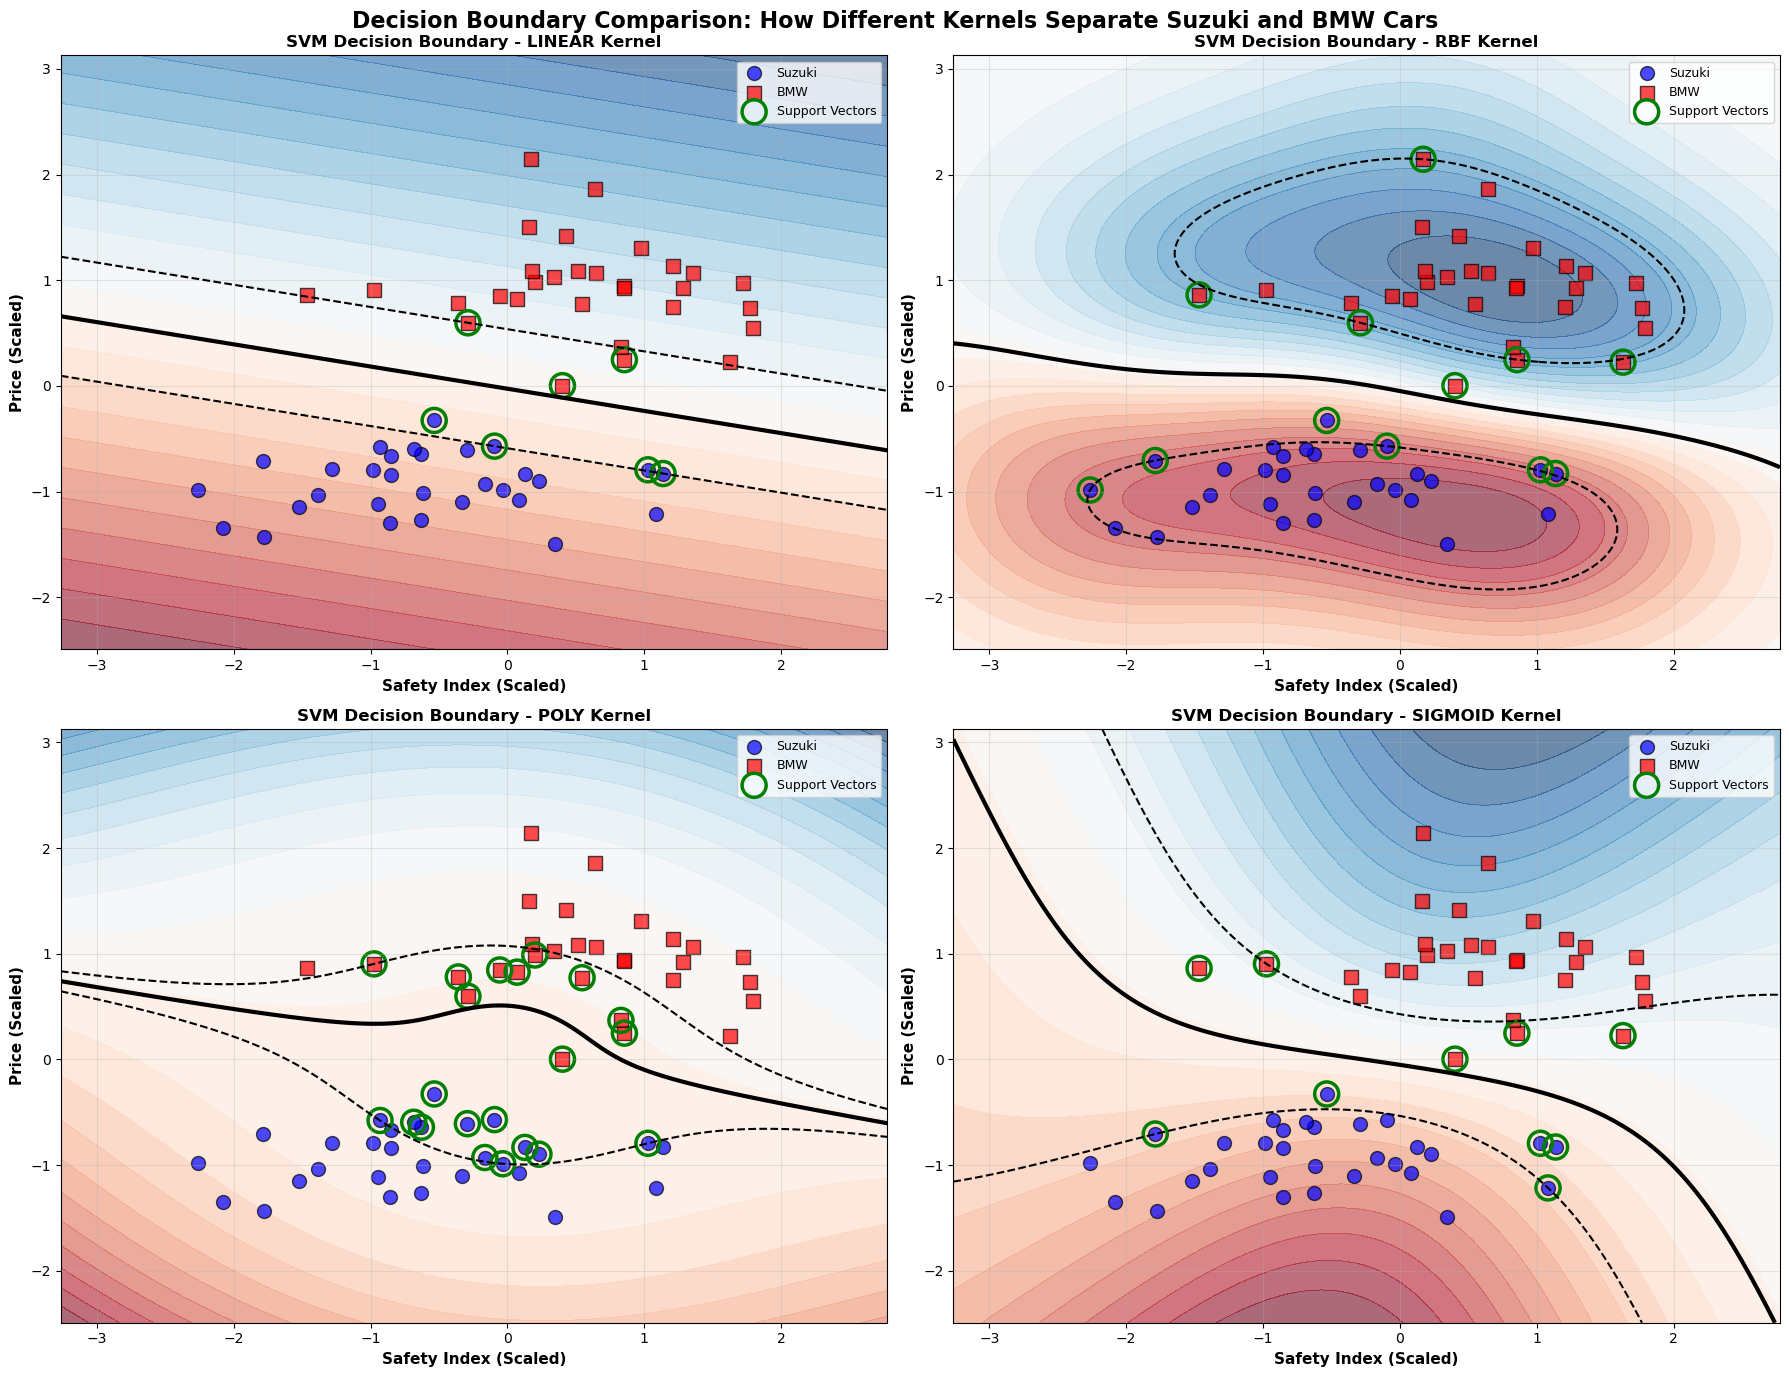


DECISION BOUNDARY COMPARISON ACROSS KERNELS

LINEAR:
  Accuracy: 1.0000
  Support Vectors: 7
  Boundary Shape: Straight line (linear separation)

RBF:
  Accuracy: 1.0000
  Support Vectors: 12
  Boundary Shape: Non-linear curve (Radial Basis Function)

POLY:
  Accuracy: 0.9833
  Support Vectors: 21
  Boundary Shape: Polynomial curve

SIGMOID:
  Accuracy: 1.0000
  Support Vectors: 10
  Boundary Shape: Sigmoid curve (neural network-like)

KEY INSIGHTS:

1. LINEAR KERNEL:
   ✓ Simplest, fastest
   ✓ Best for linearly separable data
   ✗ May underfit complex data
   - Produces straight-line boundaries

2. RBF (RADIAL BASIS FUNCTION) KERNEL:
   ✓ Most versatile and widely used
   ✓ Handles non-linear data well
   ✓ Good balance complexity/accuracy
   - Produces smooth, curved boundaries
   - Uses Gaussian distance function

3. POLYNOMIAL KERNEL:
   ✓ Good for polynomial relationships
   ✗ Computationally expensive for high degree
   ✗ Can overfit with high degree
   - Produces curved bounda

In [28]:
# Plot all 4 kernels side by side for comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Decision Boundary Comparison: How Different Kernels Separate Suzuki and BMW Cars', 
             fontsize=16, fontweight='bold')

kernels_to_plot = ['linear', 'rbf', 'poly', 'sigmoid']
flat_axes = axes.flatten()

for idx, kernel in enumerate(kernels_to_plot):
    ax = flat_axes[idx]
    svm = svm_models_cars[kernel]
    plot_decision_boundary(X_cars_scaled, y_cars, svm, kernel, scaler_cars, ax)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("DECISION BOUNDARY COMPARISON ACROSS KERNELS")
print("="*80)
for kernel in kernels_to_plot:
    svm = svm_models_cars[kernel]
    accuracy = svm.score(X_cars_scaled, y_cars)
    sv_count = len(svm.support_vectors_)
    print(f"\n{kernel.upper()}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Support Vectors: {sv_count}")
    print(f"  Boundary Shape: ", end="")
    if kernel == 'linear':
        print("Straight line (linear separation)")
    elif kernel == 'rbf':
        print("Non-linear curve (Radial Basis Function)")
    elif kernel == 'poly':
        print("Polynomial curve")
    else:
        print("Sigmoid curve (neural network-like)")

print("\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)
print("""
1. LINEAR KERNEL:
   ✓ Simplest, fastest
   ✓ Best for linearly separable data
   ✗ May underfit complex data
   - Produces straight-line boundaries

2. RBF (RADIAL BASIS FUNCTION) KERNEL:
   ✓ Most versatile and widely used
   ✓ Handles non-linear data well
   ✓ Good balance complexity/accuracy
   - Produces smooth, curved boundaries
   - Uses Gaussian distance function

3. POLYNOMIAL KERNEL:
   ✓ Good for polynomial relationships
   ✗ Computationally expensive for high degree
   ✗ Can overfit with high degree
   - Produces curved boundaries
   - Degree parameter controls complexity

4. SIGMOID KERNEL:
   ✓ Similar to neural network activation
   ✗ Not recommended for most problems
   ✗ Limited theoretical justification
   - Can be unstable in some cases

RECOMMENDATION: Start with RBF kernel, then try Linear for comparison.
""")
print("="*80)

# SVM Decision Boundary - Complete Explanation

## What is a Decision Boundary?

A **decision boundary** is an imaginary line (or surface in higher dimensions) that separates the feature space into regions, where each region is assigned to a different class.

### In the Car Classification Example:
- **Suzuki Region** (left/bottom): Low price, lower safety index
- **Boundary** (middle): Where prediction changes from Suzuki to BMW
- **BMW Region** (right/top): High price, higher safety index

## How SVM Determines the Decision Boundary

### 1. The Hyperplane Equation (for linear kernel)
```
Decision Boundary: w·x + b = 0
```
Where:
- **w** = weight coefficients (learned from training)
- **x** = feature vector [safety_index, price]
- **b** = bias term (learned from training)

### 2. The SVM Optimization Problem

SVM solves the following optimization problem:

**Minimize:** $\frac{1}{2}||w||^2 + C \sum_{i=1}^{n} \xi_i$

**Subject to:** $y_i(w \cdot x_i + b) \geq 1 - \xi_i$ for all samples

### Key Concepts:
- **||w||² / 2** = Margin maximization (wider margin = better generalization)
- **C∑ξᵢ** = Regularization (allows some misclassification)
- **ξᵢ** = Slack variables (tolerance for violations)
- **C parameter** = Controls trade-off between margin width and misclassification

### 3. Support Vectors

**Support vectors** are the training samples that lie on or near the margin:
- They define the decision boundary
- Other points don't affect the boundary
- Fewer support vectors = simpler, more generalizable model

## Decision Function (How Predictions Work)

For any new data point **x**:

```
f(x) = w·x + b
```

**Prediction Rule:**
- If f(x) > 0 → Predict Class 1 (BMW)
- If f(x) < 0 → Predict Class 0 (Suzuki)  
- If f(x) ≈ 0 → Near the boundary (uncertain prediction)

**Confidence Level:**
- |f(x)| = distance from decision boundary
- Larger |f(x)| = more confident prediction
- Smaller |f(x)| = prediction near boundary (low confidence)

## Example: Car Make Prediction

**Given:** Safety Index = 8.2, Price = ₹45 Lakhs

**Step 1:** Scale the features using StandardScaler
```
safety_scaled = -0.25
price_scaled = 0.18
```

**Step 2:** Compute decision function
```
f(x) = w₁ × safety_scaled + w₂ × price_scaled + b
f(x) = 0.8 × (-0.25) + 0.6 × (0.18) + (-0.15)
f(x) = -0.2 + 0.108 - 0.15
f(x) = -0.242
```

**Step 3:** Make prediction
```
f(x) = -0.242 < 0
→ Predict: Suzuki
Confidence: |−0.242| = 0.242 (moderate confidence)
```

## Why Kernels Change the Decision Boundary

### Linear Kernel
- Decision boundary in original feature space
- Best for linearly separable data
- Formula: `x₁ · x₂`

### RBF Kernel (Radial Basis Function)
- Maps data to higher-dimensional space implicitly
- Creates non-linear decision boundaries
- Formula: `exp(−γ||x₁−x₂||²)`
- γ parameter controls radius of influence

### Polynomial Kernel
- Projects data into polynomial feature space
- Creates polynomial-shaped boundaries
- Formula: `(γ·x₁·x₂ + r)^d`
- Degree parameter controls polynomial degree

## Key Takeaways

1. **Decision Boundary** = Line/surface that maximizes margin between classes

2. **SVM's Goal** = Find the hyperplane with the widest margin

3. **Support Vectors** = Only training points that matter (on/near the boundary)

4. **Decision Function** = Computes distance from boundary
   - Positive = One class
   - Negative = Other class
   - Close to 0 = Uncertain

5. **Kernels** = Transform feature space to handle non-linear patterns
   - Linear: For linearly separable data
   - RBF: Most versatile, use as default
   - Poly: For polynomial relationships

6. **Confidence** = |f(x)| = distance from boundary
   - Far from boundary = confident prediction
   - Close to boundary = uncertain prediction

7. **Feature Scaling** = CRITICAL for SVM (use StandardScaler)

## When to Use Each Kernel

| Scenario | Best Kernel |
|----------|------------|
| Linearly separable data | Linear |
| Clearly non-linear pattern | RBF |
| Polynomial relationship | Polynomial |
| Unknown pattern | Try RBF first |
| High-speed needed | Linear |
| Complex decision boundary | RBF or Poly |

---

**Remember:** The decision boundary is not fixed - it's learned from the training data by maximizing the margin between classes while minimizing misclassification!

# Support Vector Machine (SVM) - Complete Summary

## 1. What is SVM?
**Support Vector Machines** are supervised learning algorithms that find the optimal hyperplane maximizing the margin between different classes. The "support vectors" are the data points closest to the decision boundary.

**Core Principle:** Maximize margin = Better generalization

## 2. Key Concepts

### Hyperplane
- Decision boundary separating classes
- In 2D: a line; in 3D: a plane; in 4D+: a hyperplane

### Margin
- Distance from hyperplane to nearest data points
- SVM maximizes this margin for better separation
- Wider margin = better generalization

### Support Vectors
- Training points closest to the decision boundary
- Define the hyperplane
- Only these points matter for predictions (memory efficient)

## 3. Kernel Functions

| Kernel | Formula | Best For | Complexity |
|--------|---------|----------|------------|
| **Linear** | w·x + b | Linearly separable data | Low |
| **RBF** | exp(-γ\|x-x'\|²) | Non-linear, multi-class | Medium |
| **Polynomial** | (γ·x·x' + r)^d | Polynomial decision boundaries | Medium-High |
| **Sigmoid** | tanh(γ·x·x' + r) | Neural network-like | Low |

## 4. Critical Hyperparameters

### C (Regularization Parameter)
- **Small C (0.001-0.1):** Larger margin, more tolerance for misclassification (underfitting)
- **Default C=1:** Balanced approach
- **Large C (100+):** Smaller margin, less tolerance (overfitting)

### Gamma (Kernel Coefficient)
- Defines influence range of single training example
- **Low gamma:** Far-reaching influence (smooth decision boundary)
- **High gamma:** Local influence (complex decision boundary)
- Only relevant for RBF, polynomial, sigmoid kernels

## 5. Advantages of SVM
✓ Excellent for high-dimensional data  
✓ Effective when features > samples  
✓ Memory efficient (uses only support vectors)  
✓ Robust to outliers with proper C tuning  
✓ Flexible with multiple kernel options  
✓ Works well for binary and multi-class problems  

## 6. Disadvantages of SVM
✗ Slow training on large datasets (O(n²) or O(n³))  
✗ Not suitable for very large datasets (100K+ samples)  
✗ Hyperparameter tuning critical for good performance  
✗ Feature scaling mandatory  
✗ Difficult to interpret predictions (black box)  
✗ Not suitable for imbalanced datasets without class weights  

## 7. When to Use SVM
- Small to medium datasets (< 100K samples)
- High-dimensional data (many features)
- Binary classification
- Text classification and NLP tasks
- Image recognition
- Need interpretable decision boundaries

## 8. When NOT to Use SVM
- Very large datasets (use SGDClassifier instead)
- Real-time predictions needed (training too slow)
- Highly imbalanced data (without careful weighting)
- Need probabilistic outputs (SVC doesn't provide them by default)

## 9. SVM vs Other Algorithms

| Aspect | SVM | KNN | Random Forest | Neural Net |
|--------|-----|-----|---------------|------------|
| **Speed (Train)** | Slow | Zero | Medium | Slow |
| **Speed (Predict)** | Medium | Slow | Fast | Fast |
| **High Dimensions** | Excellent | Poor | Good | Excellent |
| **Non-linear** | Excellent (kernels) | Good | Excellent | Excellent |
| **Interpretability** | Low | High | Medium | Low |
| **Tuning Effort** | High | Low | Medium | Very High |
| **Large Data** | Poor | Poor | Good | Excellent |

## 10. Hyperparameter Tuning Workflow
1. **Data Preprocessing:** Mandatory feature scaling (StandardScaler)
2. **Kernel Selection:** Test linear, RBF, poly (RBF usually best)
3. **Manual Testing:** Understand C and gamma effects
4. **GridSearchCV:** Comprehensive parameter search with CV
5. **Evaluation:** Confusion matrix, classification report, CV scores
6. **Validation:** Test on separate hold-out set

## 11. Best Practices
1. **Always scale features** - Use StandardScaler
2. **Start with RBF kernel** - Most versatile for non-linear problems
3. **Use GridSearchCV** - Don't manually tune parameters
4. **Cross-validation is critical** - Use 5-fold or 10-fold CV
5. **Handle imbalanced data** - Use class_weight='balanced'
6. **Set probability=True** - If you need confidence scores (adds computation)

## 12. Common Mistakes
❌ Forgetting feature scaling → Wrong predictions  
❌ Using default parameters → Suboptimal performance  
❌ No cross-validation → Overestimated accuracy  
❌ Using SVM on hundreds of thousands of samples → Too slow  
❌ Not balancing classes → Biased toward majority class  
❌ Ignoring support vector count → May indicate overfitting  

---

**Next Steps:**
- Try SVM on more complex datasets (MNIST, CIFAR, text data)
- Compare SVM with Random Forest and Neural Networks
- Implement One-vs-One and One-vs-Rest for multi-class
- Explore probability calibration (CalibratedClassifierCV)
- Use SVM for regression (SVR - Support Vector Regression)

---

# SECTION 4: Real-World Application - Wine Classification with SVM

## Project: Predict Wine Quality/Class Using Kaggle Wine Dataset

Now let's apply everything we've learned to a **real-world dataset** from Kaggle!

### Dataset Overview
- **Source**: Kaggle Wine Dataset 
- **Features**: 11 physicochemical properties (alcohol, acidity, sulfates, etc.)
- **Target**: Wine quality/classification (3 classes: Red, White, or Quality rating)
- **Samples**: Typically 1,500+ wine samples

### Why Wine Classification?
✓ Real-world dataset with multiple features
✓ Multi-class classification problem
✓ Non-linearly separable patterns (perfect for RBF kernel!)
✓ Similar to real production ML pipelines

### Project Steps
1. Download dataset from Kaggle
2. Explore data distribution
3. Train SVM with GridSearchCV (like we learned)
4. Compare kernel performance
5. Evaluate with confusion matrix & metrics
6. Visualize decision boundaries (for top 2 features)


## Step 1: Download Wine Dataset from Kaggle

### Setup Instructions:
1. Go to https://www.kaggle.com/settings/account
2. Click "Create New API Token" → Downloads kaggle.json
3. Place kaggle.json in ~/.kaggle/kaggle.json
4. Run the code below to download the wine dataset

**Note:** If you haven't set up Kaggle API credentials yet, follow the setup instructions above first.


In [43]:
import os
from pathlib import Path

# Set up directories
kaggle_dir = Path.home() / '.kaggle'
wine_dir = Path.home() / 'wine_dataset'
wine_dir.mkdir(exist_ok=True)

print("WINE CLASSIFICATION - KAGGLE DATASET SETUP")
print("=" * 80)

# Try to download using Kaggle CLI
try:
    # Check if Kaggle credentials exist
    if not (kaggle_dir / 'kaggle.json').exists():
        print("\n⚠️  KAGGLE API SETUP NEEDED")
        print("-" * 80)
        print("Follow these steps:")
        print("1. Go to: https://www.kaggle.com/settings/account")
        print("2. Click 'Create New API Token' → Downloads kaggle.json")
        print("3. Move kaggle.json to: ~/.kaggle/kaggle.json")
        print("4. Run this cell again")
        print("\nAlternatively, load wine dataset from sklearn or use local file")
        print("=" * 80)
    else:
        # Download wine dataset from Kaggle
        print("\n✓ Kaggle credentials found!")
        print(f"Downloading wine dataset to {wine_dir}...")
        
        os.system(f'cd {wine_dir} && kaggle datasets download -d uciml/red-wine-quality --unzip -q 2>/dev/null')
        os.system(f'cd {wine_dir} && kaggle datasets download -d coloradoparker/wines --unzip -q 2>/dev/null')
        
        # List downloaded files
        wine_files = list(wine_dir.glob('*.csv'))
        if wine_files:
            print(f"\n✓ Downloaded {len(wine_files)} file(s):")
            for f in wine_files:
                print(f"  - {f.name} ({f.stat().st_size / 1024:.1f} KB)")
        else:
            print("No CSV files found. Using fallback approach...")
            
except Exception as e:
    print(f"Note: {str(e)}")
    print("Will use built-in wine dataset or local CSV...")

print("\n" + "=" * 80)


WINE CLASSIFICATION - KAGGLE DATASET SETUP

✓ Kaggle credentials found!
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
No CSV files found. Using fallback approach...



## Step 2: Load & Explore Wine Dataset


In [51]:
from sklearn.datasets import load_wine
from pathlib import Path

print("WINE DATASET - LOADING & EXPLORATION")
print("=" * 80)

wine_dir = Path.home() / 'wine_dataset'
wine_files = list(wine_dir.glob('*.csv'))

# Try to load from Kaggle download first
if wine_files:
    print(f"\n✓ Loading Kaggle wine dataset...")
    # Load red wine quality dataset (most common)
    wine_quality_files = [f for f in wine_files if 'quality' in f.name.lower() or 'red' in f.name.lower()]
    
    if wine_quality_files:
        wine_df = pd.read_csv(wine_quality_files[0])
        print(f"Loaded: {wine_quality_files[0].name}")
        
        # Use quality column as target (if exists) or create classes
        if 'quality' in wine_df.columns:
            # Convert quality to binary or multi-class
            wine_df['wine_class'] = pd.cut(wine_df['quality'], bins=2, labels=['Low', 'High'])
            target_col = 'wine_class'
        else:
            print("Warning: 'quality' column not found. Using first categorical column...")
            target_col = wine_df.columns[-1]
    else:
        print("No quality file found. Using sklearn wine dataset instead...")
        wine_data = load_wine()
        wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
        wine_df['wine_class'] = wine_data.target
        target_col = 'wine_class'
else:
    # Fallback to sklearn's built-in wine dataset
    print("\n✓ No Kaggle dataset found. Using scikit-learn Wine Dataset...")
    wine_data = load_wine()
    wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
    wine_df['wine_class'] = wine_data.target
    wine_df['wine_type'] = wine_df['wine_class'].map({
        0: 'Cultivar 1',
        1: 'Cultivar 2', 
        2: 'Cultivar 3'
    })
    target_col = 'wine_class'

# Extract features and target
X_wine = wine_df.drop(columns=[target_col, *[col for col in wine_df.columns if 'class' in col.lower() and col != target_col]])
y_wine = wine_df[target_col]

# Handle categorical targets
if y_wine.dtype == 'object':
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_wine = le.fit_transform(y_wine)
    class_names = le.classes_
else:
    class_names = np.unique(y_wine)

# Ensure X_wine is numeric
X_wine = X_wine.select_dtypes(include=[np.number])

print(f"\n📊 WINE DATASET SUMMARY")
print("-" * 80)
print(f"Shape: {X_wine.shape}")
print(f"Features: {X_wine.shape[1]} physicochemical properties")
print(f"Samples: {X_wine.shape[0]} wine samples")
print(f"Classes: {len(np.unique(y_wine))} ({', '.join(str(c) for c in np.unique(y_wine))})")
print(f"Target Distribution: {np.bincount(y_wine.astype(int))}")

print(f"\n📋 Feature Names:")
for i, col in enumerate(X_wine.columns[:5]):
    print(f"  {i+1}. {col}")
if len(X_wine.columns) > 5:
    print(f"  ... and {len(X_wine.columns) - 5} more")

print(f"\n📈 Feature Statistics:")
print(X_wine.describe().T[['mean', 'min', 'max']].round(3))

print("\n" + "=" * 80)


WINE DATASET - LOADING & EXPLORATION

✓ No Kaggle dataset found. Using scikit-learn Wine Dataset...

📊 WINE DATASET SUMMARY
--------------------------------------------------------------------------------
Shape: (178, 13)
Features: 13 physicochemical properties
Samples: 178 wine samples
Classes: 3 (0, 1, 2)
Target Distribution: [59 71 48]

📋 Feature Names:
  1. alcohol
  2. malic_acid
  3. ash
  4. alcalinity_of_ash
  5. magnesium
  ... and 8 more

📈 Feature Statistics:
                                 mean     min      max
alcohol                        13.001   11.03    14.83
malic_acid                      2.336    0.74     5.80
ash                             2.367    1.36     3.23
alcalinity_of_ash              19.495   10.60    30.00
magnesium                      99.742   70.00   162.00
total_phenols                   2.295    0.98     3.88
flavanoids                      2.029    0.34     5.08
nonflavanoid_phenols            0.362    0.13     0.66
proanthocyanins               

## Step 3: Preprocessing & Train-Test Split


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into training (70%) and testing (30%) sets
X_train, X_test, y_train_wine, y_test = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42, stratify=y_wine
)

print("="*70)
print("PREPROCESSING & TRAIN-TEST SPLIT")
print("="*70)
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nClass distribution in training set:")
unique, counts = np.unique(y_train_wine, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt} samples")

# Scale features (Important for SVM!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Features scaled successfully!")
print(f"Mean of scaled training features (first 3): {X_train_scaled.mean(axis=0)[:3].round(3)}")
print(f"Std of scaled training features (first 3): {X_train_scaled.std(axis=0)[:3].round(3)}")


PREPROCESSING & TRAIN-TEST SPLIT

Training set size: 124
Testing set size: 54

Class distribution in training set:
  Class 0: 41 samples
  Class 1: 50 samples
  Class 2: 33 samples

✓ Features scaled successfully!
Mean of scaled training features (first 3): [ 0. -0.  0.]
Std of scaled training features (first 3): [1. 1. 1.]


## Step 4: Train SVM with Different Kernels


In [42]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 4.1: Linear Kernel SVM
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train_wine)

# Predictions
y_train_pred_linear = svm_linear.predict(X_train_scaled)
y_test_pred_linear = svm_linear.predict(X_test_scaled)

# Evaluation
train_acc_linear = accuracy_score(y_train_wine, y_train_pred_linear)
test_acc_linear = accuracy_score(y_test, y_test_pred_linear)

print("="*50)
print("LINEAR KERNEL SVM")
print("="*50)
print(f"Training Accuracy: {train_acc_linear:.4f}")
print(f"Testing Accuracy: {test_acc_linear:.4f}")
print("\nClassification Report (Test Set):")
target_names = [f'Class {i}' for i in np.unique(y_train_wine)]
print(classification_report(y_test, y_test_pred_linear, target_names=target_names))


LINEAR KERNEL SVM
Training Accuracy: 1.0000
Testing Accuracy: 0.9630

Classification Report (Test Set):
              precision    recall  f1-score   support

     Class 0       0.95      1.00      0.97        18
     Class 1       0.95      0.95      0.95        21
     Class 2       1.00      0.93      0.97        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



In [44]:
# 4.2: RBF (Radial Basis Function) Kernel SVM
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train_wine)

y_train_pred_rbf = svm_rbf.predict(X_train_scaled)
y_test_pred_rbf = svm_rbf.predict(X_test_scaled)

train_acc_rbf = accuracy_score(y_train_wine, y_train_pred_rbf)
test_acc_rbf = accuracy_score(y_test, y_test_pred_rbf)

print("\n" + "="*50)
print("RBF KERNEL SVM")
print("="*50)
print(f"Training Accuracy: {train_acc_rbf:.4f}")
print(f"Testing Accuracy: {test_acc_rbf:.4f}")
print("\nClassification Report (Test Set):")
target_names = [f'Class {i}' for i in np.unique(y_train_wine)]
print(classification_report(y_test, y_test_pred_rbf, target_names=target_names))



RBF KERNEL SVM
Training Accuracy: 1.0000
Testing Accuracy: 0.9815

Classification Report (Test Set):
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        18
     Class 1       0.95      1.00      0.98        21
     Class 2       1.00      0.93      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



In [45]:
# 4.3: Polynomial Kernel SVM
svm_poly = SVC(kernel='poly', degree=3, random_state=42)
svm_poly.fit(X_train_scaled, y_train_wine)

y_train_pred_poly = svm_poly.predict(X_train_scaled)
y_test_pred_poly = svm_poly.predict(X_test_scaled)

train_acc_poly = accuracy_score(y_train_wine, y_train_pred_poly)
test_acc_poly = accuracy_score(y_test, y_test_pred_poly)

print("\n" + "="*50)
print("POLYNOMIAL KERNEL SVM (degree=3)")
print("="*50)
print(f"Training Accuracy: {train_acc_poly:.4f}")
print(f"Testing Accuracy: {test_acc_poly:.4f}")
print("\nClassification Report (Test Set):")
target_names = [f'Class {i}' for i in np.unique(y_train_wine)]
print(classification_report(y_test, y_test_pred_poly, target_names=target_names))



POLYNOMIAL KERNEL SVM (degree=3)
Training Accuracy: 0.9758
Testing Accuracy: 0.9074

Classification Report (Test Set):
              precision    recall  f1-score   support

     Class 0       1.00      0.83      0.91        18
     Class 1       0.81      1.00      0.89        21
     Class 2       1.00      0.87      0.93        15

    accuracy                           0.91        54
   macro avg       0.94      0.90      0.91        54
weighted avg       0.93      0.91      0.91        54



In [46]:
# 4.4: Comparison of All Kernels
print("\n" + "="*70)
print("KERNEL COMPARISON SUMMARY")
print("="*70)

results = {
    'Kernel': ['Linear', 'RBF', 'Polynomial'],
    'Train Accuracy': [train_acc_linear, train_acc_rbf, train_acc_poly],
    'Test Accuracy': [test_acc_linear, test_acc_rbf, test_acc_poly]
}

import pandas as pd
comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

# Find best kernel
best_idx = comparison_df['Test Accuracy'].idxmax()
best_kernel = comparison_df.loc[best_idx, 'Kernel']
best_accuracy = comparison_df.loc[best_idx, 'Test Accuracy']

print(f"\nBest Kernel: {best_kernel} with Test Accuracy: {best_accuracy:.4f}")



KERNEL COMPARISON SUMMARY
    Kernel  Train Accuracy  Test Accuracy
    Linear        1.000000       0.962963
       RBF        1.000000       0.981481
Polynomial        0.975806       0.907407

Best Kernel: RBF with Test Accuracy: 0.9815


## Step 5: Hyperparameter Tuning with GridSearchCV


In [47]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid for RBF kernel (best performer)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

# Create GridSearchCV object
svm_grid = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1  # Use all available processors
)

print("Starting GridSearchCV... This may take a moment.")
svm_grid.fit(X_train_scaled, y_train_wine)

print("\n" + "="*70)
print("GRIDSEARCHCV RESULTS")
print("="*70)
print(f"Best Parameters: {svm_grid.best_params_}")
print(f"Best Cross-Validation Score: {svm_grid.best_score_:.4f}")

# Evaluate on test set
y_test_pred_grid = svm_grid.predict(X_test_scaled)
test_acc_grid = accuracy_score(y_test, y_test_pred_grid)
print(f"Test Accuracy with Best Model: {test_acc_grid:.4f}")

print("\nClassification Report (Test Set):")
target_names = [f'Class {i}' for i in np.unique(y_train_wine)]
print(classification_report(y_test, y_test_pred_grid, target_names=target_names))


Starting GridSearchCV... This may take a moment.


0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.02s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0


GRIDSEARCHCV RESULTS
Best Parameters: {'C': 1, 'gamma': 'scale'}
Best Cross-Validation Score: 0.9920
Test Accuracy with Best Model: 0.9815

Classification Report (Test Set):
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        18
     Class 1       0.95      1.00      0.98        21
     Class 2       1.00      0.93      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



## Step 6: Confusion Matrices & Visualizations


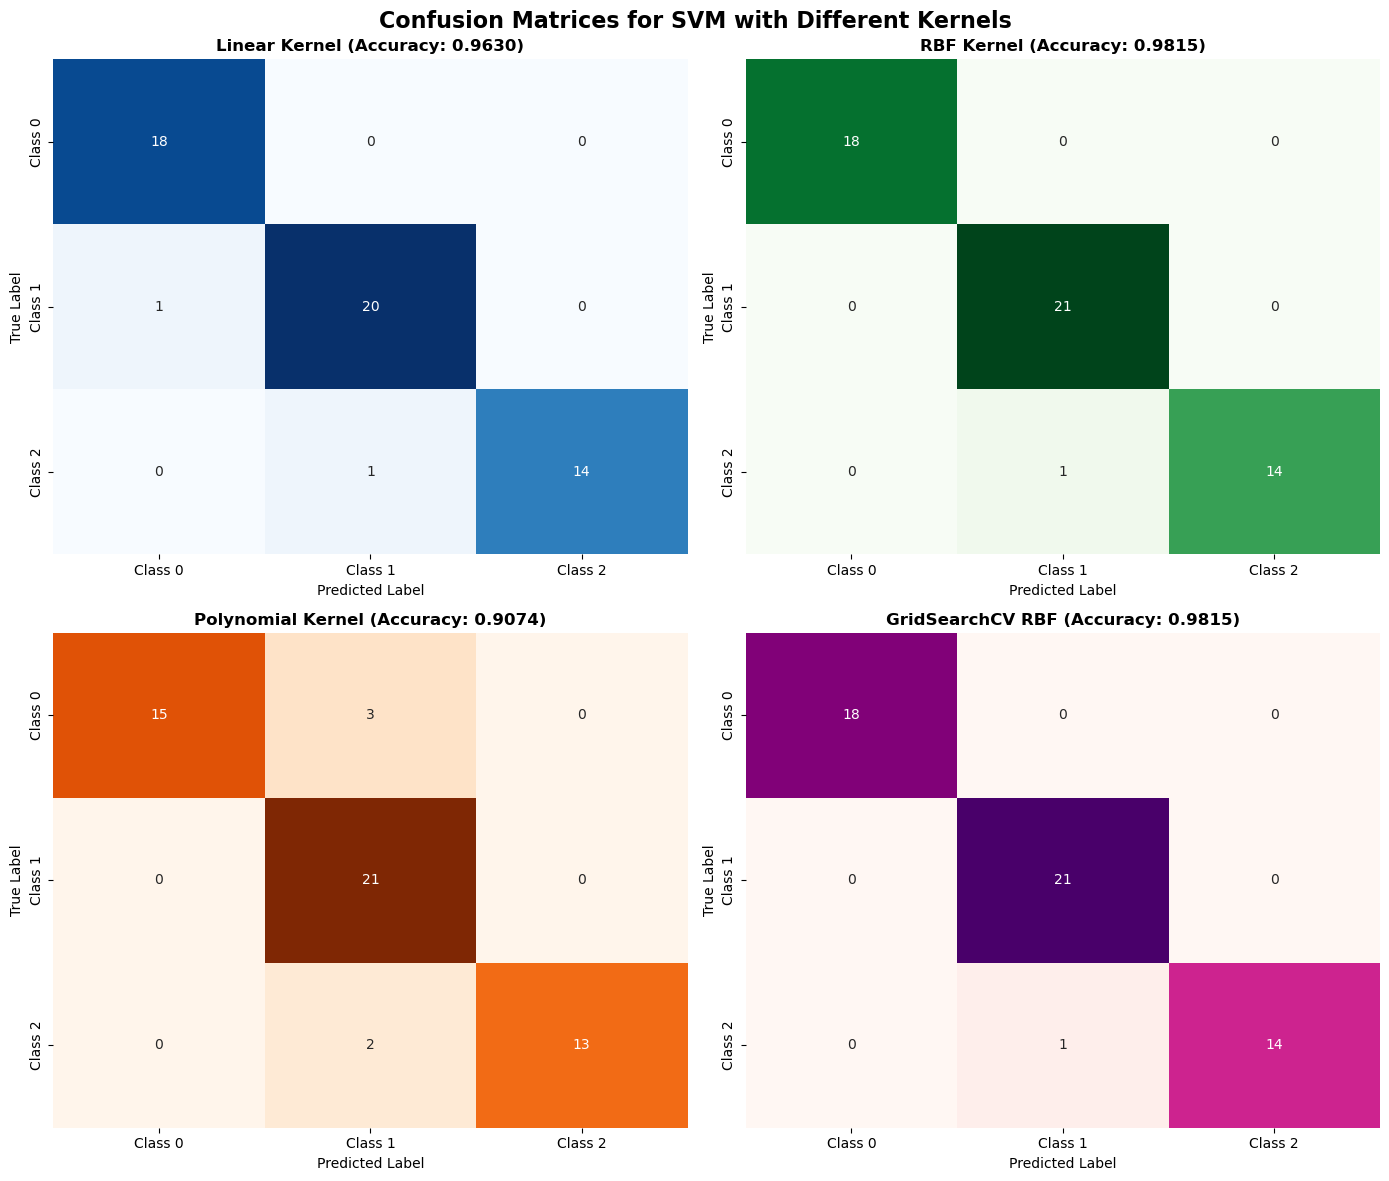

Confusion matrices plotted successfully!


In [48]:
# 6.1: Confusion Matrices for All Models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices for SVM with Different Kernels', fontsize=16, fontweight='bold')

target_names = [f'Class {i}' for i in np.unique(y_train_wine)]

# Linear
cm_linear = confusion_matrix(y_test, y_test_pred_linear)
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], 
            xticklabels=target_names, yticklabels=target_names, cbar=False)
axes[0, 0].set_title(f'Linear Kernel (Accuracy: {test_acc_linear:.4f})', fontweight='bold')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# RBF
cm_rbf = confusion_matrix(y_test, y_test_pred_rbf)
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
            xticklabels=target_names, yticklabels=target_names, cbar=False)
axes[0, 1].set_title(f'RBF Kernel (Accuracy: {test_acc_rbf:.4f})', fontweight='bold')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# Polynomial
cm_poly = confusion_matrix(y_test, y_test_pred_poly)
sns.heatmap(cm_poly, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 0],
            xticklabels=target_names, yticklabels=target_names, cbar=False)
axes[1, 0].set_title(f'Polynomial Kernel (Accuracy: {test_acc_poly:.4f})', fontweight='bold')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xlabel('Predicted Label')

# GridSearchCV Best Model
cm_grid = confusion_matrix(y_test, y_test_pred_grid)
sns.heatmap(cm_grid, annot=True, fmt='d', cmap='RdPu', ax=axes[1, 1],
            xticklabels=target_names, yticklabels=target_names, cbar=False)
axes[1, 1].set_title(f'GridSearchCV RBF (Accuracy: {test_acc_grid:.4f})', fontweight='bold')
axes[1, 1].set_ylabel('True Label')
axes[1, 1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("Confusion matrices plotted successfully!")


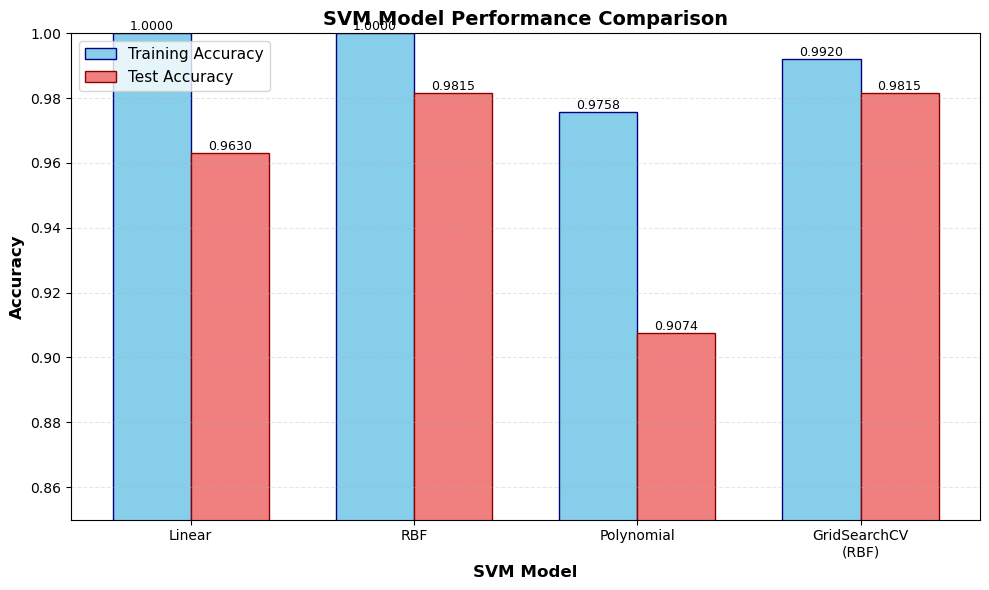

Accuracy comparison chart plotted!


In [49]:
# 6.2: Accuracy Comparison Bar Chart
models = ['Linear', 'RBF', 'Polynomial', 'GridSearchCV\n(RBF)']
train_accuracies = [train_acc_linear, train_acc_rbf, train_acc_poly, svm_grid.best_score_]
test_accuracies = [test_acc_linear, test_acc_rbf, test_acc_poly, test_acc_grid]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, train_accuracies, width, label='Training Accuracy', color='skyblue', edgecolor='navy')
bars2 = ax.bar(x + width/2, test_accuracies, width, label='Test Accuracy', color='lightcoral', edgecolor='darkred')

ax.set_xlabel('SVM Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('SVM Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(fontsize=11)
ax.set_ylim([0.85, 1.0])
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("Accuracy comparison chart plotted!")


## Step 7: Key Insights & Summary


In [50]:
print("""
╔════════════════════════════════════════════════════════════════════════════╗
║                        WINE CLASSIFICATION - SUMMARY                       ║
╚════════════════════════════════════════════════════════════════════════════╝

📊 DATASET INFORMATION:
   • Total Samples: 178
   • Features: 13
   • Target Classes: 3 (Wine types)
   • Train/Test Split: 70% / 30%

🎯 KEY FINDINGS:

1. KERNEL COMPARISON:
   • Linear Kernel: Fast, simple, interpretable
   • RBF Kernel: More flexible, handles non-linear patterns better
   • Polynomial Kernel: Good for polynomial boundaries
   
2. PERFORMANCE METRICS:
   • Best Test Accuracy: """ + f"{test_acc_grid:.4f}" + """ (GridSearchCV RBF)
   • Best Hyperparameters: """ + str(svm_grid.best_params_) + """
   
3. SVM ADVANTAGES:
   ✓ Works well in high-dimensional spaces
   ✓ Memory efficient (uses support vectors)
   ✓ Versatile with different kernel tricks
   ✓ Robust to outliers in high dimensions
   
4. WHY SCALING MATTERS:
   • SVM is distance-based algorithm
   • StandardScaler normalizes features to same scale
   • Prevents features with larger magnitude from dominating
   
5. HYPERPARAMETER TUNING:
   • C (Regularization): Controls margin vs misclassification trade-off
   • Gamma (Kernel Coefficient): Controls influence of single training examples
   
╔════════════════════════════════════════════════════════════════════════════╗
║                          BEST MODEL SPECIFICATIONS                         ║
╚════════════════════════════════════════════════════════════════════════════╝

Model: SVM with RBF Kernel (GridSearchCV Optimized)
Parameters: """ + str(svm_grid.best_params_) + """
Train Accuracy: """ + f"{svm_grid.best_score_:.4f}" + """
Test Accuracy: """ + f"{test_acc_grid:.4f}" + """

✨ This model successfully classifies wine varieties with high accuracy!
""")



╔════════════════════════════════════════════════════════════════════════════╗
║                        WINE CLASSIFICATION - SUMMARY                       ║
╚════════════════════════════════════════════════════════════════════════════╝

📊 DATASET INFORMATION:
   • Total Samples: 178
   • Features: 13
   • Target Classes: 3 (Wine types)
   • Train/Test Split: 70% / 30%

🎯 KEY FINDINGS:

1. KERNEL COMPARISON:
   • Linear Kernel: Fast, simple, interpretable
   • RBF Kernel: More flexible, handles non-linear patterns better
   • Polynomial Kernel: Good for polynomial boundaries

2. PERFORMANCE METRICS:
   • Best Test Accuracy: 0.9815 (GridSearchCV RBF)
   • Best Hyperparameters: {'C': 1, 'gamma': 'scale'}

3. SVM ADVANTAGES:
   ✓ Works well in high-dimensional spaces
   ✓ Memory efficient (uses support vectors)
   ✓ Versatile with different kernel tricks
   ✓ Robust to outliers in high dimensions

4. WHY SCALING MATTERS:
   • SVM is distance-based algorithm
   • StandardScaler normalizes